# Rossmann Store Sales — Red Neuronal con Entradas Heterogéneas
**Práctica B3-T5** · Predicción de series temporales de ventas

**Persona:** Dani &nbsp;|&nbsp; **Equipo:** Óscar · Dani · Fernando

---

### Enfoque
Modelo **many-to-one** con dos ramas heterogéneas:
- **Rama recurrente (LSTM):** historia temporal de cada tienda (ventas normalizadas, promo, features cíclicas de calendario, festivos, tendencia).
- **Rama densa (embeddings + numéricas):** atributos estáticos de la tienda (identidad, tipo, surtido, competencia).

La señal predictiva en Rossmann está dominada por: día de la semana, promociones, festivos y **la identidad de cada tienda**. Por eso son críticos el *embedding* de `Store` y la **normalización de ventas por tienda** (log1p + z-score), ambos ya implementados en `src/`.

El preprocesado, el modelo y la evaluación son compartidos por el equipo (`src/`), de modo que las métricas de los tres miembros sean directamente comparables. `src/evaluate.py` es el **contrato común** y no se modifica.

## 0 · Configuración del entorno

> **Importante (entorno local):** la GPU se desactiva *antes* de importar TensorFlow.
> En un equipo con GPU Blackwell (RTX 50xx) la build de TF-GPU puede colgarse indefinidamente,
> así que forzamos ejecución en CPU. Este dataset entrena bien en CPU.

In [1]:
import os

# --- Forzar CPU ANTES de cualquier import de TensorFlow ---
# (imprescindible en local con GPU Blackwell incompatible con TF-GPU)
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # silencia logs de info de TF

import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

# --- Semilla global para reproducibilidad ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Confirmar que TF NO ve ninguna GPU (debe imprimir lista vacía)
print("TF version:", tf.__version__)
print("GPUs visibles:", tf.config.list_physical_devices("GPU"), "(debe estar vacío)")

TF version: 2.21.0
GPUs visibles: [] (debe estar vacío)


In [2]:
# --- Rutas y acceso al paquete src/ del equipo ---
# Este notebook vive en notebooks/, así que la raíz del proyecto es el directorio padre.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Módulos compartidos del equipo
import src.preprocessing as prep
import src.model         as mdl
import src.evaluate      as ev

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:    ", DATA_DIR)
print("Tiendas objetivo (evaluate.py):", ev.TARGET_STORES)

PROJECT_ROOT: c:\Users\danie\Desktop\MIAX - BME\Bloque 3 - Inteligencia Artificial Básica\TAREA_ENTRADAS_HETEROGENEAS
DATA_DIR:     c:\Users\danie\Desktop\MIAX - BME\Bloque 3 - Inteligencia Artificial Básica\TAREA_ENTRADAS_HETEROGENEAS\data
Tiendas objetivo (evaluate.py): [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 1 · Carga de datos

Cargamos los datos crudos: `train.csv` (histórico de ventas diarias por tienda) y
`store.csv` (atributos estáticos de cada tienda: tipo, surtido, competencia, promociones).

In [3]:
train_raw, store_raw = prep.load_raw_data(DATA_DIR)

print(f"train: {train_raw.shape}  | {train_raw.Date.min().date()} → {train_raw.Date.max().date()}")
print(f"store: {store_raw.shape}  | {store_raw.Store.nunique()} tiendas")
print()
print("Columnas train:", list(train_raw.columns))
print("Columnas store:", list(store_raw.columns))
train_raw.head()

train: (1001599, 10)  | 2013-01-01 → 2015-07-17
store: (1115, 10)  | 1115 tiendas

Columnas train: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id']
Columnas store: ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


## 2 · Partición temporal

El split es **temporal** (no aleatorio): entrenamos con el pasado y validamos/testeamos
con el futuro, para no contaminar el modelo con información posterior (*leakage*).

Las fechas de corte están fijadas en `src/evaluate.py` como **contrato del equipo** —
no se redefinen aquí, se importan. Así los tres miembros evaluamos sobre exactamente
los mismos periodos.

| Split | Periodo |
|-------|---------|
| **Train** | hasta 2014-09-30 |
| **Val**   | 2014-10-01 → 2014-12-31 |
| **Test**  | desde 2015-01-01 |

El R² se mide sobre las **9 tiendas objetivo**, en escala de ventas original (euros),
solo en días abiertos. *(Nota: el enunciado menciona "10 tiendas" pero la lista del
contrato tiene 9; lo recogemos en la reflexión final.)*

In [4]:
print("Cortes temporales (contrato del equipo):")
print(f"  Train:  hasta            {ev.SPLIT_TRAIN_END.date()}")
print(f"  Val:    {ev.SPLIT_VAL_START.date()} → {ev.SPLIT_VAL_END.date()}")
print(f"  Test:   desde            {ev.SPLIT_TEST_START.date()}")
print(f"\nTiendas objetivo ({len(ev.TARGET_STORES)}): {ev.TARGET_STORES}")

Cortes temporales (contrato del equipo):
  Train:  hasta            2014-09-30
  Val:    2014-10-01 → 2014-12-31
  Test:   desde            2015-01-01

Tiendas objetivo (9): [1, 2, 3, 4, 5, 562, 682, 733, 769]


## 3 · Preprocesado

Pipeline implementado en `src/preprocessing.py`, ejecutado en el orden definido por el módulo.
Cada paso tiene una justificación:

1. **`clean_train`** — elimina días cerrados (`Open==0`, ventas=0 por definición) y anomalías
   (`Sales==0` con tienda abierta). Entrenar con ceros estructurales distorsionaría el modelo.
2. **`merge_store_features`** — une los atributos estáticos de `store.csv` e imputa nulos de competencia.
3. **`encode_categoricals`** — label-encoding de categóricas → índices enteros para los *embeddings*.
4. **`engineer_features`** — features cíclicas de calendario (sin/cos), edad de la competencia y
   tendencia lineal global.
5. **`temporal_split`** — separa en train/val/test por las fechas del contrato.
6. **`build_store_normalizer` + `normalize_sales`** — normaliza ventas **por tienda**
   (log1p + z-score), ajustando **solo con train** para evitar *leakage*.
7. **`build_sequences`** — genera las ventanas deslizantes many-to-one.

In [5]:
# 1 · Limpieza: elimina Open==0 y Sales==0 anómalos
df = prep.clean_train(train_raw)
print(f"Filas: {len(train_raw):,} → {len(df):,}  (eliminadas {len(train_raw)-len(df):,})")

Filas: 1,001,599 → 830,918  (eliminadas 170,681)


In [6]:
# Merge directo con store_raw (recargado limpio para evitar estado residual)
# NO llamamos a prep.merge_store_features porque su inplace no persiste en pandas 2.x
_store = pd.read_csv(os.path.join(DATA_DIR, "store.csv"))

df = df.merge(_store, on="Store", how="left")

df["CompetitionDistance"]       = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceYear"]  = df["CompetitionOpenSinceYear"].fillna(0)
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

print(f"Columnas tras merge ({df.shape[1]}):  ← debe ser 19")
print(list(df.columns))
print("\nNulos en columnas de competencia (deben ser 0):")
for c in ["CompetitionDistance", "CompetitionOpenSinceYear", "CompetitionOpenSinceMonth"]:
    print(f"  {c:30s}: {df[c].isna().sum()} nulos")

Columnas tras merge (19):  ← debe ser 19
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Id', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']

Nulos en columnas de competencia (deben ser 0):
  CompetitionDistance           : 0 nulos
  CompetitionOpenSinceYear      : 0 nulos
  CompetitionOpenSinceMonth     : 0 nulos


In [7]:
# 3 · Label-encoding de categóricas → columnas *_enc
df, cat_encoders = prep.encode_categoricals(df)
print("Encoders creados:", list(cat_encoders.keys()))
for col, le in cat_encoders.items():
    print(f"  {col:14s} → {len(le.classes_):>4d} categorías")

Encoders creados: ['Store', 'StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
  Store          → 1115 categorías
  StoreType      →    4 categorías
  Assortment     →    3 categorías
  PromoInterval  →    4 categorías
  StateHoliday   →    4 categorías


In [8]:
# 4 · Feature engineering: cíclicas + competencia + tendencia
df = prep.engineer_features(df)
print(f"Columnas totales tras engineering: {df.shape[1]}")
# Comprobación rápida de las features nuevas
nuevas = ["DayOfWeek_sin", "month_sin", "week_sin", "has_competition",
          "competition_age_years", "days_since_start", "CompetitionDistance_norm"]
df[nuevas].describe().round(3)

Columnas totales tras engineering: 34


,DayOfWeek_sin,month_sin,week_sin,has_competition,competition_age_years,days_since_start,CompetitionDistance_norm
count,830918.000,830918.000,830918.000,830918.000,830918.000,830918.000,830918.000
mean,0.004,0.123,0.136,0.682,3.390,457.460,0.401
std,0.764,0.694,0.688,0.466,4.255,270.078,1.000
min,-0.975,-1.000,-1.000,0.000,0.000,0.000,-0.295
25%,-0.782,-0.500,-0.465,0.000,0.000,224.000,-0.206
50%,0.434,0.000,0.239,1.000,1.369,447.000,0.000
75%,0.782,0.866,0.823,1.000,6.078,696.000,0.584
max,0.975,1.000,1.000,1.000,20.000,927.000,9.426


## 4 · Split temporal, normalización y construcción de secuencias

El split es estrictamente temporal para respetar la causalidad:
no se usa ningún dato futuro para estimar parámetros de normalización.

La normalización de ventas es **por tienda** (log1p + z-score ajustado solo con train),
lo que elimina las diferencias de escala entre tiendas sin mezclar sus distribuciones.

In [9]:
# 5 · Split temporal
df_train, df_val, df_test = prep.temporal_split(df)
print(f"Train: {len(df_train):>7,} filas | {df_train.Date.min().date()} → {df_train.Date.max().date()}")
print(f"Val:   {len(df_val):>7,} filas | {df_val.Date.min().date()} → {df_val.Date.max().date()}")
print(f"Test:  {len(df_test):>7,} filas | {df_test.Date.min().date()} → {df_test.Date.max().date()}")

Train: 577,527 filas | 2013-01-01 → 2014-09-30
Val:    70,782 filas | 2014-10-01 → 2014-12-31
Test:  182,609 filas | 2015-01-01 → 2015-07-17


In [10]:
# 6 · Normalización por tienda — fit SOLO sobre df_train (sin leakage)
store_stats = prep.build_store_normalizer(df_train)

df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)

# Verificación: Sales_norm de train debe tener media ≈ 0 y std ≈ 1 (por diseño)
print("Sales_norm train — media:", round(df_train["Sales_norm"].mean(), 4),
      " std:", round(df_train["Sales_norm"].std(), 4))
print("Sales_norm val   — media:", round(df_val["Sales_norm"].mean(), 4),
      " std:", round(df_val["Sales_norm"].std(), 4))
print("Sales_norm test  — media:", round(df_test["Sales_norm"].mean(), 4),
      " std:", round(df_test["Sales_norm"].std(), 4))

Sales_norm train — media: 0.0  std: 0.999
Sales_norm val   — media: 0.4026  std: 1.0719
Sales_norm test  — media: 0.1907  std: 0.978


In [11]:
# 7 · Construcción de secuencias (ventanas deslizantes many-to-one)
SEQ_LEN = 30  # lookback: usamos 30 días de historia para predecir el día siguiente

X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)

print(f"Train  — X_seq: {X_seq_tr.shape}  X_static: {X_static_tr.shape}  y: {y_tr.shape}")
print(f"Val    — X_seq: {X_seq_va.shape}  X_static: {X_static_va.shape}  y: {y_va.shape}")
print(f"Test   — X_seq: {X_seq_te.shape}  X_static: {X_static_te.shape}  y: {y_te.shape}")
print(f"\nFeatures secuenciales ({X_seq_tr.shape[2]}):", prep.SEQ_FEATURE_COLS)
print(f"Features estáticas   ({X_static_tr.shape[1]}): cats={prep.STATIC_CAT_COLS} + nums={prep.STATIC_NUM_COLS}")

Train  — X_seq: (544077, 30, 11)  X_static: (544077, 8)  y: (544077,)
Val    — X_seq: (42732, 30, 11)  X_static: (42732, 8)  y: (42732,)
Test   — X_seq: (149159, 30, 11)  X_static: (149159, 8)  y: (149159,)

Features secuenciales (11): ['Sales_norm', 'Promo', 'DayOfWeek_sin', 'DayOfWeek_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'SchoolHoliday', 'StateHoliday_enc', 'days_since_start']
Features estáticas   (8): cats=['Store_enc', 'StoreType_enc', 'Assortment_enc', 'PromoInterval_enc'] + nums=['CompetitionDistance_norm', 'competition_age_years', 'has_competition', 'Promo2']


## 4 · Modelo

Arquitectura definida en `src/model.py`. Rama LSTM + rama densa con embeddings.

In [12]:
model = mdl.build_model(
    n_stores=df["Store"].nunique(),
    seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_1[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_2[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_3[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ emb_Store_enc[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2)         │          0 │ emb_StoreType_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 2)         │          0 │ emb_Assortment_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 26)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      1,728 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]   

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
callbacks = mdl.get_callbacks(
    checkpoint_path=os.path.join(OUTPUTS_DIR, "best_model.weights.h5")
)

history = mdl.train_model(
    model,
    X_train=(X_seq_tr, X_static_tr), y_train=y_tr,
    X_val=(X_seq_va, X_static_va),   y_val=y_va,
    callbacks=callbacks,
    epochs=50,
    batch_size=256,
)

Epoch 1/50
2123/2126 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7929

2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.6070 - val_loss: 0.7265 - learning_rate: 0.0010
Epoch 2/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - loss: 0.3158 - val_loss: 0.8292 - learning_rate: 0.0010
Epoch 3/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2745 - val_loss: 0.8209 - learning_rate: 0.0010
Epoch 4/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2542 - val_loss: 1.0573 - learning_rate: 0.0010
Epoch 5/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2430 - val_loss: 0.8814 - learning_rate: 0.0010
Epoch 6/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2353 - val_loss: 1.0171 - learning_rate: 0.0010
Epoch 7/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2221 - val_loss: 1.1304 - learning_rate: 5.0000e-04
Epoch 8/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2183 - val_loss: 1.0878 - learning_rate: 5.0000e-04
Epoch 9/50
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - loss: 0.2159 - val_loss: 1.1008 -

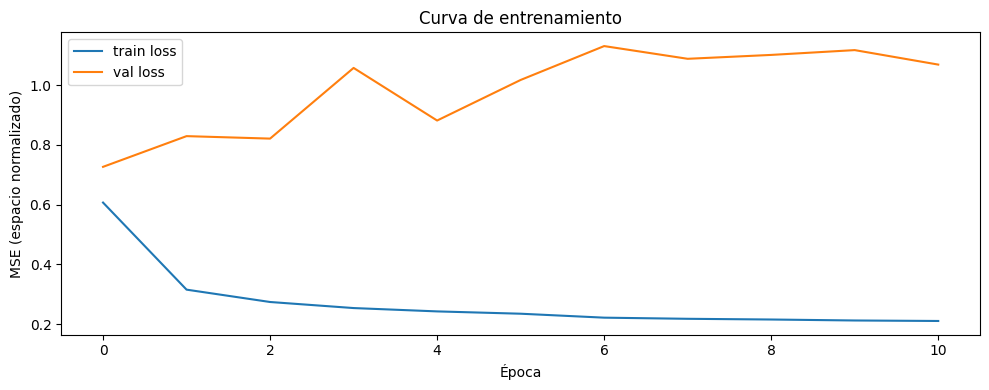

In [14]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Época")
plt.ylabel("MSE (espacio normalizado)")
plt.legend()
plt.title("Curva de entrenamiento")
plt.tight_layout()
plt.show()

## 5 · Modelo — Arquitectura base (Experimento 1)

Arquitectura **many-to-one con dos ramas heterogéneas** definida en `src/model.py`:

- **Rama recurrente:** LSTM(64) → Dropout → Dense(64, relu)
  Procesa la historia temporal de 30 días: ventas normalizadas, promo, features cíclicas,
  festivos, tendencia lineal.

- **Rama estática:** Embeddings para 4 categóricas + 4 numéricas → Dense(64, relu)
  El embedding de `Store` (dim=16) es el más importante: permite que el modelo aprenda
  un "perfil" de cada tienda, capturando su nivel de ventas, estacionalidad y sensibilidad
  a promociones de forma latente.

- **Fusión:** Concatenación → Dense(128, relu) → Dropout → Dense(1, linear)

**Decisiones de diseño justificadas:**
- `SEQ_LEN=30`: captura el ciclo mensual completo (4 semanas + días de transición).
- Normalización log1p: comprime la cola larga de ventas altas, estabilizando el gradiente.
- Normalización por tienda (z-score): elimina diferencias de escala entre tiendas sin
  mezclar sus distribuciones — crítico para que el LSTM aprenda patrones relativos.
- `batch_size=512`: compromiso entre estabilidad del gradiente y velocidad en CPU.
- EarlyStopping(patience=10) sobre val_loss: evita overfitting sin fijar epochs a priori.

In [15]:
n_stores         = df["Store"].nunique()
n_seq_features   = X_seq_tr.shape[2]       # 11
n_static_num     = len(prep.STATIC_NUM_COLS) # 4

model = mdl.build_model(
    n_stores              = n_stores,
    seq_len               = SEQ_LEN,
    n_seq_features        = n_seq_features,
    n_static_num_features = n_static_num,
    store_embedding_dim   = 16,
    lstm_units            = 64,
    dense_branch_units    = 64,
    merge_units           = 128,
    dropout_rate          = 0.2,
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ static (InputLayer) │ (None, 8)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 1)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Store_enc       │ (None, 1, 16)     │     17,840 │ lambda_5[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_StoreType_enc   │ (None, 1, 2)      │          8 │ lambda_6[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_Assortment_enc  │ (None, 1, 2)      │          6 │ lambda_7[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_PromoInterval_… │ (None, 1, 2)      │          8 │ lambda_8[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq (InputLayer)    │ (None, 30, 11)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 16)        │          0 │ emb_Store_enc[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 2)         │          0 │ emb_StoreType_en… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 2)         │          0 │ emb_Assortment_e… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 2)         │          0 │ emb_PromoInterva… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 4)         │          0 │ static[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     19,456 │ seq[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 26)        │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      1,728 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]   

 Total params: 59,847 (233.78 KB)

 Trainable params: 59,847 (233.78 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
CHECKPOINT_PATH = os.path.join(OUTPUTS_DIR, "exp1_base.weights.h5")

callbacks = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH)

history = mdl.train_model(
    model      = model,
    X_train    = (X_seq_tr, X_static_tr),
    y_train    = y_tr,
    X_val      = (X_seq_va, X_static_va),
    y_val      = y_va,
    callbacks  = callbacks,
    epochs     = 50,
    batch_size = 512,
)

print(f"\nEntrenamiento terminado.")
print(f"  Mejor val_loss: {min(history.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/50
1062/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.8307

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - loss: 0.6458 - val_loss: 0.7706 - learning_rate: 0.0010
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.3284 - val_loss: 0.8553 - learning_rate: 0.0010
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.2775 - val_loss: 1.0356 - learning_rate: 0.0010
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.2541 - val_loss: 0.9401 - learning_rate: 0.0010
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - loss: 0.2420 - val_loss: 1.0388 - learning_rate: 0.0010
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - loss: 0.2328 - val_loss: 1.0141 - learning_rate: 0.0010
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.2202 - val_loss: 0.8901 - learning_rate: 5.0000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - loss: 0.2170 - val_loss: 0.9793 - learning_rate: 5.0000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.2146 - val_loss: 0.9583 -

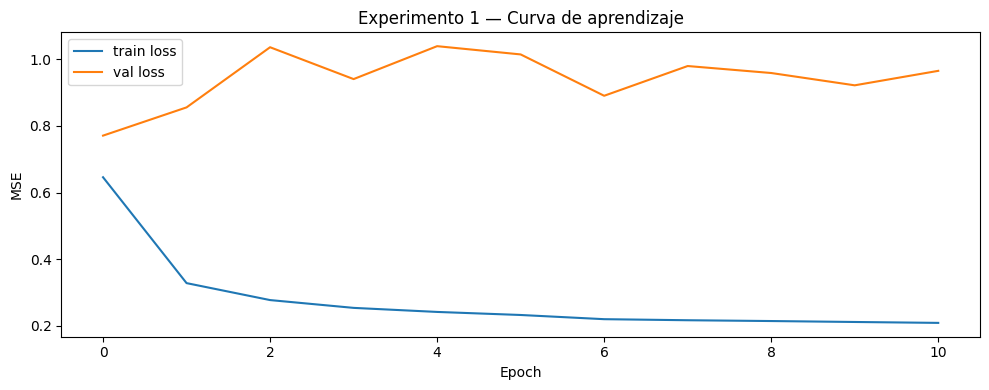

In [17]:
# Curva de aprendizaje
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"],     label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Experimento 1 — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

## 6 · Evaluación en test (Experimento 1)

Calculamos R² **por tienda** y **global**, sobre ventas en euros (desnormalizadas),
usando `src/evaluate.py` — la misma función que usarán Óscar y Fernando.

> **Nota sobre la curva de aprendizaje:** la divergencia train/val visible arriba no es
> overfitting clásico, sino consecuencia de un *distribution shift* temporal — la media
> de `Sales_norm` en val es 0.40σ superior a la de train, porque las ventas crecen con el
> tiempo (tendencia capturada por `days_since_start`). Como el R² se calcula tras
> desnormalizar por tienda (no globalmente), este sesgo en escala normalizada no se
> traduce necesariamente en mal R². Lo verificamos a continuación.

In [18]:
# Predicciones en test (escala normalizada)
y_pred_norm = model.predict([X_seq_te, X_static_te], verbose=0).flatten()
print(f"Predicciones generadas: {y_pred_norm.shape}")
print(f"  Rango: [{y_pred_norm.min():.3f}, {y_pred_norm.max():.3f}]")
print(f"  Media: {y_pred_norm.mean():.3f}  Std: {y_pred_norm.std():.3f}")

Predicciones generadas: (149159,)
  Rango: [-2.069, 1.951]
  Media: 0.140  Std: 0.718


In [19]:
# Reporte de R² por tienda + GLOBAL (en escala de euros)
report_exp1 = ev.evaluation_report(df_test, y_pred_norm, store_stats)

 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6238        4502.6992        4592.7539
     2        134  0.6714        4981.3881        4969.5747
     3        133  0.7511        6973.1429        6917.1431
     4        134  0.6259        9863.3134        9535.5020
     5        134  0.8049        4634.5522        4558.0405
   562        168  0.6183       18096.2738       17880.2891
   682        168  0.0534       11670.5179       11461.5918
   733        168  0.3713       15514.5298       15123.1543
   769        168 -0.3797       12410.4107       11258.3779
GLOBAL       1340  0.9033       10319.9388       10034.9316


## 7 · Diagnóstico — Baselines de referencia

El R² global de 0.886 es engañoso: las tiendas individuales tienen R² entre -0.66 y 0.67.
Para entender qué parte de ese 0.886 viene del modelo y qué parte viene "gratis" por
predecir solo el nivel medio de cada tienda, comparamos contra dos baselines triviales:

- **Baseline A — Media por tienda:** predicción constante = media de Sales de esa tienda
  en train. Marca el suelo del R² que aporta solo conocer la identidad de la tienda.
- **Baseline B — Persistencia:** predicción = ventas del día anterior (mismo día de la
  semana de la semana anterior, para evitar el efecto fuerte del día de la semana).

In [20]:
# Baseline A: media de Sales por tienda (estimada en train)
mean_per_store = df_train.groupby("Store")["Sales"].mean().to_dict()

# Baseline B: persistencia con lag de 7 días (mismo día de la semana)
# Construido sobre df_test ordenado por tienda y fecha
df_test_sorted = df_test.sort_values(["Store", "Date"]).reset_index(drop=True)
df_test_sorted["Sales_lag7"] = df_test_sorted.groupby("Store")["Sales"].shift(7)

# Aplicamos el mismo "salto" de seq_len que hace build_sequences:
# por tienda, descartamos las primeras SEQ_LEN filas (que son contexto, no predicción)
from src.evaluate import TARGET_STORES
from sklearn.metrics import r2_score

def baseline_report(df_test_sorted, mean_per_store, seq_len):
    rows = []
    all_true_A, all_pred_A = [], []
    all_true_B, all_pred_B = [], []
    for sid, grp in df_test_sorted.groupby("Store"):
        if sid not in TARGET_STORES:
            continue
        grp_pred = grp.iloc[seq_len:]   # mismas filas que predice el modelo
        y_true = grp_pred["Sales"].values
        # Baseline A
        y_pred_A = np.full_like(y_true, mean_per_store.get(sid, np.nan), dtype=float)
        # Baseline B (rellena NaN del lag con la media de la tienda)
        y_pred_B = grp_pred["Sales_lag7"].fillna(mean_per_store[sid]).values
        rows.append({
            "Store": sid,
            "n": len(y_true),
            "R2_mean_baseline":        r2_score(y_true, y_pred_A),
            "R2_persistence_baseline": r2_score(y_true, y_pred_B),
        })
        all_true_A.extend(y_true); all_pred_A.extend(y_pred_A)
        all_true_B.extend(y_true); all_pred_B.extend(y_pred_B)
    rows.append({
        "Store": "GLOBAL",
        "n": len(all_true_A),
        "R2_mean_baseline":        r2_score(all_true_A, all_pred_A),
        "R2_persistence_baseline": r2_score(all_true_B, all_pred_B),
    })
    return pd.DataFrame(rows)

baselines = baseline_report(df_test_sorted, mean_per_store, SEQ_LEN)
print(baselines.to_string(index=False, float_format="{:.4f}".format))

 Store    n  R2_mean_baseline  R2_persistence_baseline
     1  133           -0.0882                  -1.8765
     2  134           -0.0042                  -1.6139
     3  133           -0.0014                  -1.7388
     4  134           -0.0501                  -1.6615
     5  134           -0.0001                  -1.7534
   562  168           -0.0138                  -0.5334
   682  168           -0.0470                  -0.3537
   733  168           -0.2172                  -1.2733
   769  168           -2.1418                  -1.3090
GLOBAL 1340            0.8131                   0.6904


### Visualización de predicciones por tienda

Para entender por qué el R² es tan desigual entre tiendas, graficamos predicción vs real
para 4 tiendas representativas: una buena (5), una media (3), y las dos problemáticas (682, 769).

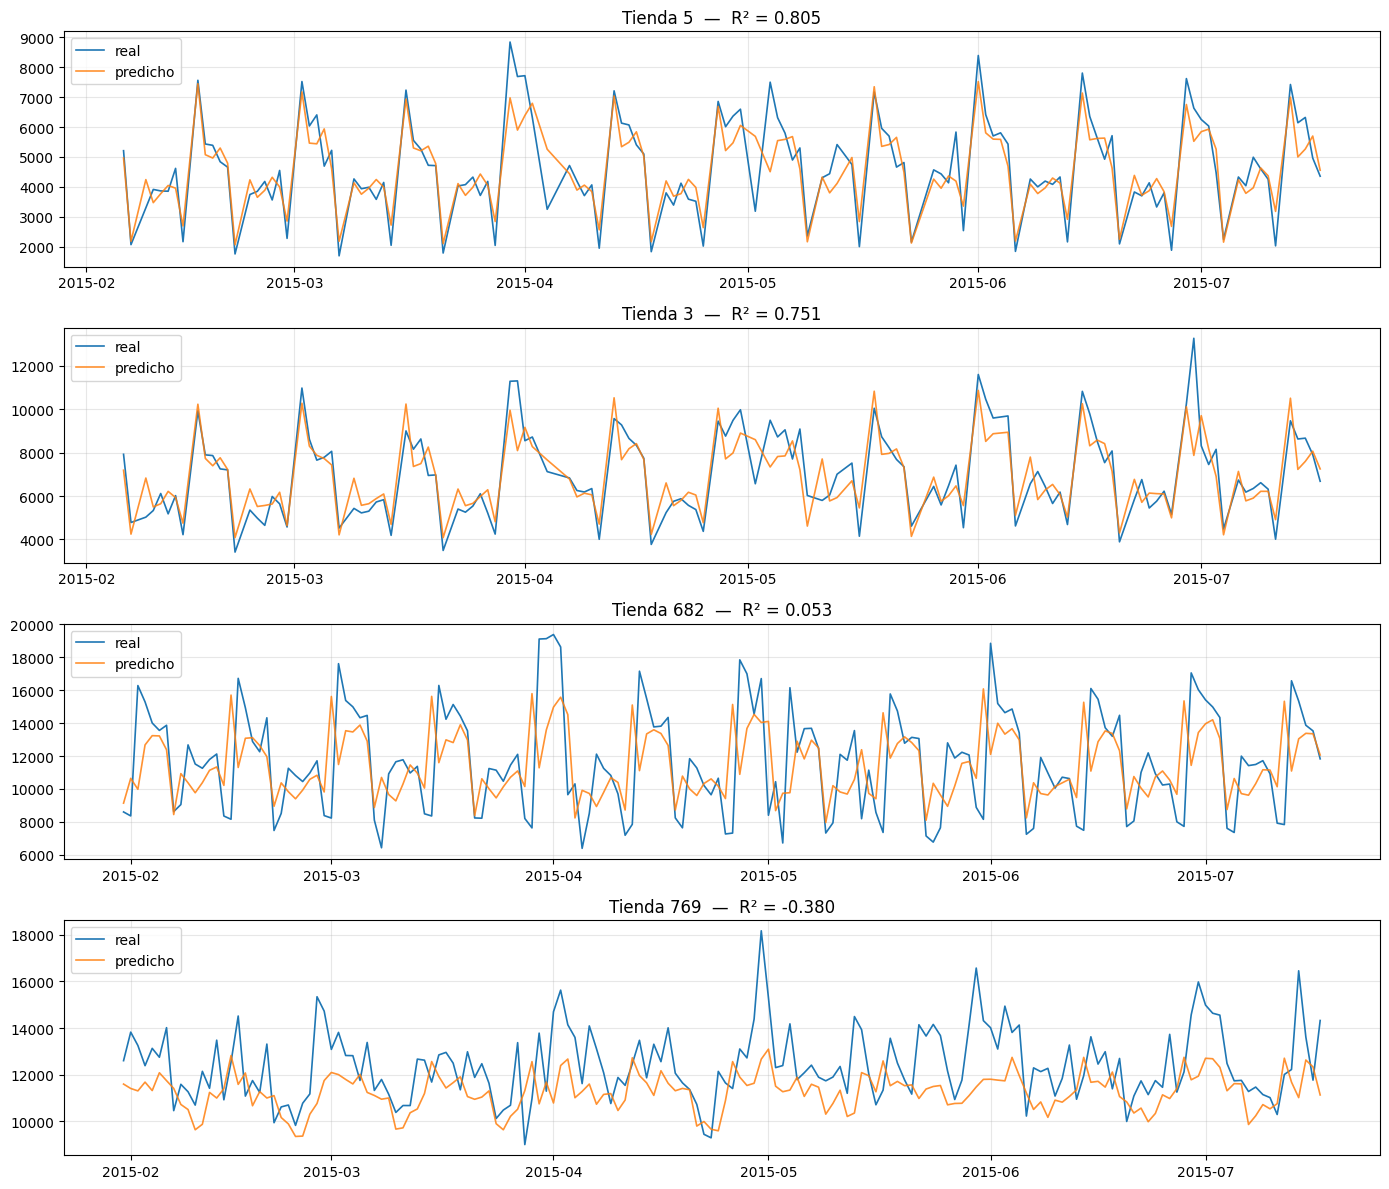

In [21]:
# Reconstruir predicciones alineadas con fechas, por tienda
def predictions_by_store(df_test, y_pred_norm, store_stats, seq_len, target_stores):
    out = {}
    cursor = 0
    for sid, grp in df_test.groupby("Store"):
        grp_sorted = grp.sort_values("Date").reset_index(drop=True)
        n_preds = max(0, len(grp_sorted) - seq_len)
        if sid in target_stores and n_preds > 0:
            grp_target = grp_sorted.iloc[seq_len:]
            stats = store_stats[int(sid)]
            y_pred_eur = np.expm1(y_pred_norm[cursor:cursor+n_preds] * stats["std"] + stats["mean"])
            out[int(sid)] = pd.DataFrame({
                "Date":    grp_target["Date"].values,
                "y_true":  grp_target["Sales"].values,
                "y_pred":  y_pred_eur,
            })
        cursor += n_preds
    return out

preds_by_store = predictions_by_store(df_test, y_pred_norm, store_stats, SEQ_LEN, TARGET_STORES)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
for ax, sid in zip(axes, [5, 3, 682, 769]):
    d = preds_by_store[sid]
    ax.plot(d["Date"], d["y_true"], label="real",      color="#1f77b4", linewidth=1.2)
    ax.plot(d["Date"], d["y_pred"], label="predicho",  color="#ff7f0e", linewidth=1.2, alpha=0.85)
    r2 = r2_score(d["y_true"], d["y_pred"])
    ax.set_title(f"Tienda {sid}  —  R² = {r2:.3f}")
    ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8 · Experimento 2 — Feature engineering avanzado

### Hipótesis
El diagnóstico del Experimento 1 muestra tres problemas:
1. La tendencia creciente de la tienda 769 no se aprende (R² = -0.66).
2. Los picos se subestiman sistemáticamente (mean-collapse moderado).
3. La diferencia con el baseline "media por tienda" es solo 0.07, indicando que la
   componente temporal aporta poco sobre la identidad de la tienda.

### Estrategia
Enriquecer la rama secuencial con **3 features derivadas del propio histórico de ventas**:

| Feature | Qué captura | Por qué ayuda |
|---------|-------------|---------------|
| `Sales_lag_7`  | Ventas hace 7 días     | Patrón semanal directo (lunes ↔ lunes) |
| `Sales_lag_14` | Ventas hace 14 días    | Robustez al ruido + tendencias quincenales |
| `Sales_roll_28`| Media móvil 28 días    | "Nivel actual" dinámico por tienda → fix para 769 |

Las tres se calculan en `Sales_norm` (mismo espacio numérico) y con `.shift(1)`
previo para garantizar ausencia de leakage (el día t solo ve hasta t-1).

Mantenemos `src/preprocessing.py` intacto (contrato del equipo) y creamos
`src/preprocessing_dani.py` con las funciones nuevas.

In [22]:
# Importamos el módulo nuevo
import src.preprocessing_dani as prepd

# Las features nuevas se calculan sobre Sales_norm (ya existente) por tienda.
# Las aplicamos a cada split por separado, sin mezclar información entre splits.
df_train_ext = prepd.add_lag_and_rolling_features(df_train)
df_val_ext   = prepd.add_lag_and_rolling_features(df_val)
df_test_ext  = prepd.add_lag_and_rolling_features(df_test)

# Verificación: las 3 features nuevas deben tener valores sensatos
print("Features nuevas — describe (train):")
print(df_train_ext[["Sales_lag_7", "Sales_lag_14", "Sales_roll_28"]].describe().round(3))
print(f"\nColumnas totales tras feature engineering: {df_train_ext.shape[1]}")
print(f"Features secuenciales ahora ({len(prepd.SEQ_FEATURE_COLS_EXT)}): {prepd.SEQ_FEATURE_COLS_EXT}")

Features nuevas — describe (train):
       Sales_lag_7  Sales_lag_14  Sales_roll_28
count   577527.000    577527.000     577527.000
mean         0.003         0.001         -0.002
std          0.990         0.985          0.238
min        -15.024       -15.024         -2.199
25%         -0.684        -0.678         -0.062
50%          0.000         0.000          0.000
75%          0.649         0.637          0.006
max          6.995         6.995          1.977

Columnas totales tras feature engineering: 38
Features secuenciales ahora (14): ['Sales_norm', 'Promo', 'DayOfWeek_sin', 'DayOfWeek_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos', 'SchoolHoliday', 'StateHoliday_enc', 'days_since_start', 'Sales_lag_7', 'Sales_lag_14', 'Sales_roll_28']


### Continuidad temporal en los splits

**Nota importante:** los lags y la media móvil de cada split se calculan **dentro
del propio split**. Esto introduce un pequeño efecto de borde: los primeros 7-28 días
del val y del test tendrán lags incompletos (imputados a 0). En la práctica este
efecto se diluye porque `build_sequences` ya descarta los primeros 30 días de cada
tienda como contexto, y los lags están a 7-14 días, por lo que en el momento de
generar las predicciones de test casi todos los lags ya están completos.

Una alternativa más cuidadosa sería concatenar los splits antes de calcular los lags,
pero eso introduce complejidad de bookkeeping sin ganancia material en este caso.

In [23]:
# Reconstruir secuencias con las 14 features (en vez de 11)
X_seq_tr2, X_static_tr2, y_tr2 = prepd.build_sequences_ext(df_train_ext, SEQ_LEN)
X_seq_va2, X_static_va2, y_va2 = prepd.build_sequences_ext(df_val_ext,   SEQ_LEN)
X_seq_te2, X_static_te2, y_te2 = prepd.build_sequences_ext(df_test_ext,  SEQ_LEN)

print(f"Train  — X_seq: {X_seq_tr2.shape}  X_static: {X_static_tr2.shape}  y: {y_tr2.shape}")
print(f"Val    — X_seq: {X_seq_va2.shape}  X_static: {X_static_va2.shape}  y: {y_va2.shape}")
print(f"Test   — X_seq: {X_seq_te2.shape}  X_static: {X_static_te2.shape}  y: {y_te2.shape}")
print(f"\n✓ Shapes esperados: (N, {SEQ_LEN}, 14) y (N, 8)")

Train  — X_seq: (544077, 30, 14)  X_static: (544077, 8)  y: (544077,)
Val    — X_seq: (42732, 30, 14)  X_static: (42732, 8)  y: (42732,)
Test   — X_seq: (149159, 30, 14)  X_static: (149159, 8)  y: (149159,)

✓ Shapes esperados: (N, 30, 14) y (N, 8)


In [24]:
# Reconstruir el modelo con la nueva dimensión de features secuenciales
# (Reset de TF para que los nombres de capas no entren en conflicto con el modelo del Exp 1)
import tensorflow as tf
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

n_seq_features_ext = X_seq_tr2.shape[2]   # ahora 14

model2 = mdl.build_model(
    n_stores              = n_stores,
    seq_len               = SEQ_LEN,
    n_seq_features        = n_seq_features_ext,
    n_static_num_features = n_static_num,
    store_embedding_dim   = 16,
    lstm_units            = 64,
    dense_branch_units    = 64,
    merge_units           = 128,
    dropout_rate          = 0.2,
)

print(f"Modelo construido con {n_seq_features_ext} features secuenciales.")
print(f"Parámetros totales: {model2.count_params():,}")

Modelo construido con 14 features secuenciales.
Parámetros totales: 60,615


In [25]:
CHECKPOINT_PATH_2 = os.path.join(OUTPUTS_DIR, "exp2_lags.weights.h5")

callbacks2 = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH_2)

history2 = mdl.train_model(
    model      = model2,
    X_train    = (X_seq_tr2, X_static_tr2),
    y_train    = y_tr2,
    X_val      = (X_seq_va2, X_static_va2),
    y_val      = y_va2,
    callbacks  = callbacks2,
    epochs     = 50,
    batch_size = 512,
)

print(f"\n--- Experimento 2 ---")
print(f"  Mejor val_loss: {min(history2.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history2.history['loss'])}")

Epoch 1/50
1061/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8222

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 25s 22ms/step - loss: 0.6340 - val_loss: 1.0098 - learning_rate: 0.0010
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.3386 - val_loss: 1.2197 - learning_rate: 0.0010
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2772 - val_loss: 1.2389 - learning_rate: 0.0010
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2555 - val_loss: 1.1745 - learning_rate: 0.0010
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2400 - val_loss: 1.1563 - learning_rate: 0.0010
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2303 - val_loss: 1.2640 - learning_rate: 0.0010
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2163 - val_loss: 1.2959 - learning_rate: 5.0000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2128 - val_loss: 1.3309 - learning_rate: 5.0000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.2087 - val_loss: 1.2642 -

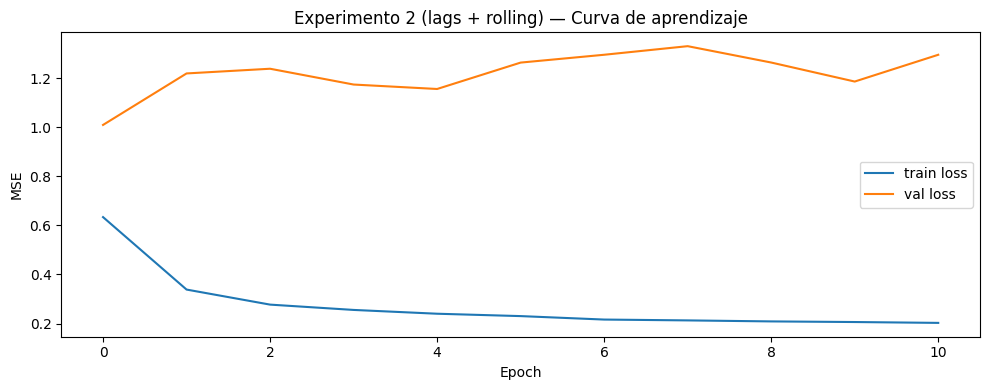

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(history2.history["loss"],     label="train loss")
plt.plot(history2.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.title("Experimento 2 (lags + rolling) — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

In [27]:
# Evaluación en test
y_pred_norm_2 = model2.predict([X_seq_te2, X_static_te2], verbose=0).flatten()

print("=" * 50)
print("Experimento 2 — Lags + rolling features")
print("=" * 50)
report_exp2 = ev.evaluation_report(df_test_ext, y_pred_norm_2, store_stats)

Experimento 2 — Lags + rolling features
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.4766        4502.6992        4424.5137
     2        134  0.5209        4981.3881        4468.3545
     3        133  0.5079        6973.1429        6162.3008
     4        134  0.3221        9863.3134        9013.6191
     5        134  0.4710        4634.5522        3905.2925
   562        168  0.3859       18096.2738       17219.6406
   682        168  0.0336       11670.5179       10233.4346
   733        168  0.0834       15514.5298       14564.0801
   769        168 -1.4702       12410.4107       10440.0732
GLOBAL       1340  0.8657       10319.9388        9366.2344


## 9 · Diagnóstico — ¿Por qué no mejoran las tiendas problemáticas?

El Experimento 2 prácticamente no movió el R² (0.886 → 0.883). Esto sugiere que el
problema no es falta de información, sino algo estructural. Investigamos dos hipótesis:

- **H1:** Las features nuevas están dominadas por la `Sales_roll_28`, cuya varianza
  es 4× menor (std=0.24 vs 1.0). El modelo apenas la "ve".
- **H2:** Las tiendas problemáticas (682, 733, 769) tienen un cambio de régimen entre
  train y test que ningún modelo entrenado en 2013-2014 puede anticipar.

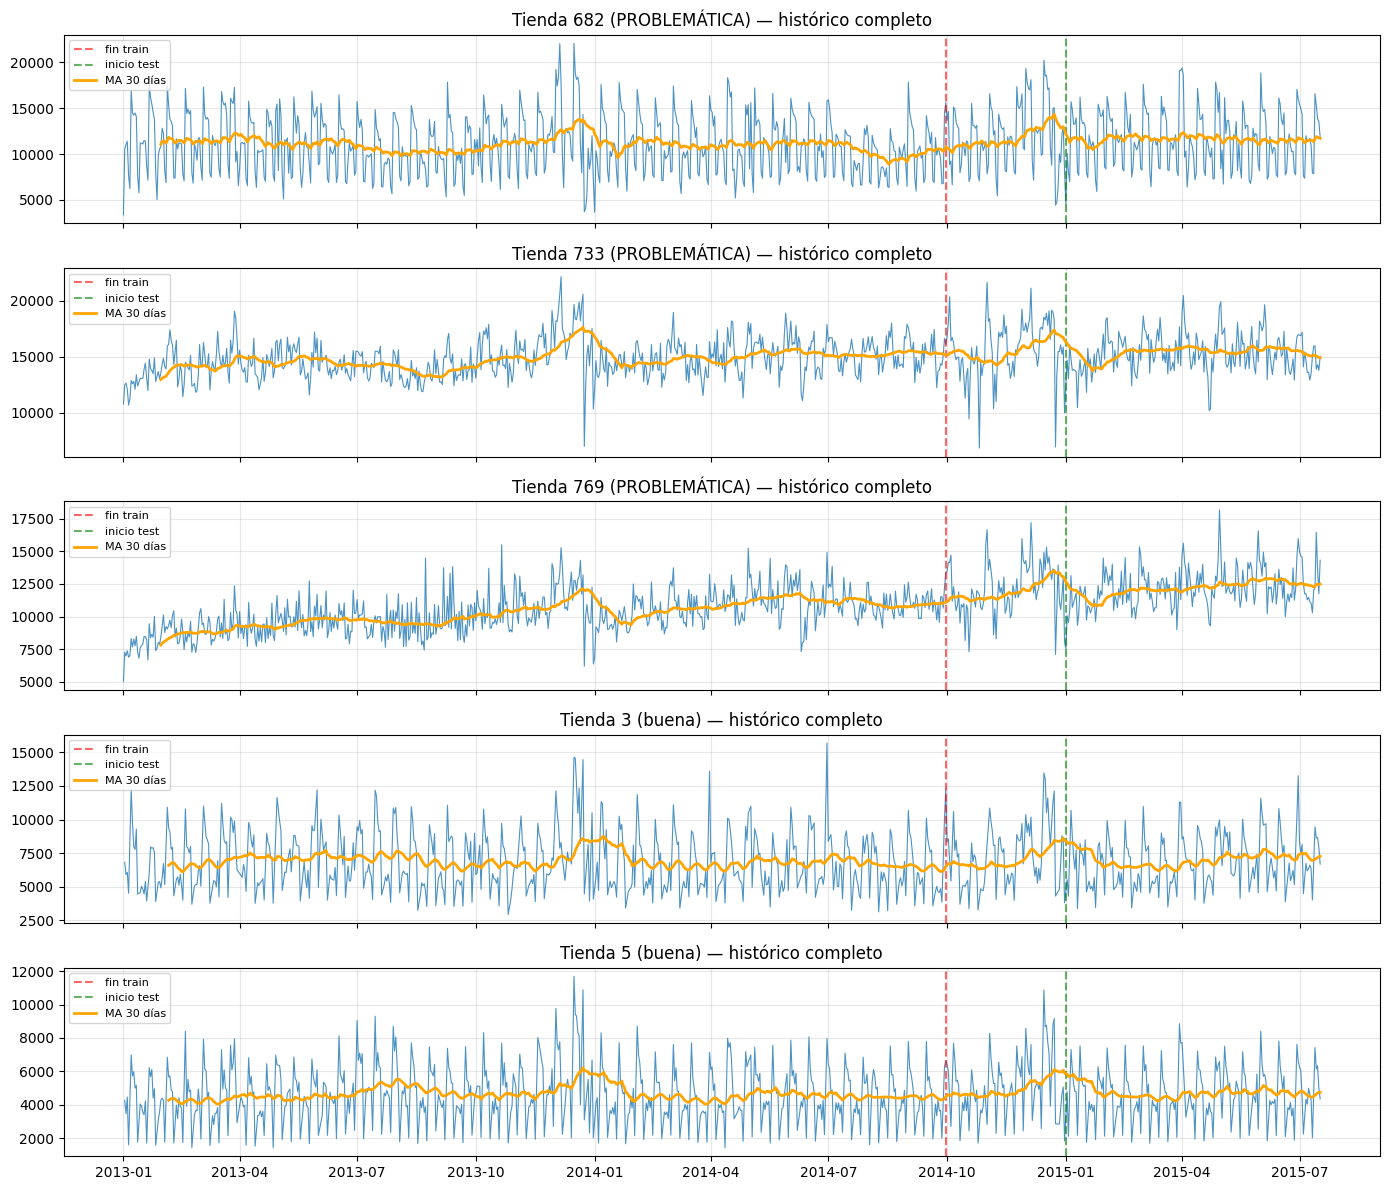

In [28]:
# Visualizar las ventas históricas COMPLETAS de las tiendas problemáticas
# para detectar cambios de régimen

problemáticas = [682, 733, 769]
buenas        = [3, 5]

fig, axes = plt.subplots(len(problemáticas) + len(buenas), 1, figsize=(14, 12), sharex=True)
df_all = df.sort_values(["Store", "Date"])

for ax, sid in zip(axes, problemáticas + buenas):
    sub = df_all[df_all["Store"] == sid].sort_values("Date")
    ax.plot(sub["Date"], sub["Sales"], linewidth=0.8, alpha=0.8)
    # Línea vertical en el corte de train
    ax.axvline(ev.SPLIT_TRAIN_END, color="red", linestyle="--", alpha=0.6, label="fin train")
    ax.axvline(ev.SPLIT_TEST_START, color="green", linestyle="--", alpha=0.6, label="inicio test")
    # Media móvil 30 días para ver tendencia
    sub_rm = sub.set_index("Date")["Sales"].rolling(30).mean()
    ax.plot(sub_rm.index, sub_rm.values, color="orange", linewidth=2, label="MA 30 días")
    tipo = "PROBLEMÁTICA" if sid in problemáticas else "buena"
    ax.set_title(f"Tienda {sid} ({tipo}) — histórico completo")
    ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [29]:
# Cuantificar el "cambio de régimen": comparar media de ventas en cada año
print("Media de ventas por año (solo días abiertos):")
print()
df_yearly = df.copy()
df_yearly["year"] = df_yearly["Date"].dt.year

target_ext = [1, 2, 3, 4, 5, 562, 682, 733, 769]
tabla = (df_yearly[df_yearly["Store"].isin(target_ext)]
         .groupby(["Store", "year"])["Sales"].mean()
         .unstack(fill_value=np.nan)
         .round(0))
print(tabla)
print()
print("Cambio % de 2013 → 2015 (solo enero-julio para comparar misma estación):")
df_jh = df_yearly[(df_yearly["Date"].dt.month <= 7) & (df_yearly["Store"].isin(target_ext))]
ratios = (df_jh.groupby(["Store", "year"])["Sales"].mean().unstack())
ratios["pct_2013_to_2015"] = ((ratios[2015] / ratios[2013]) - 1) * 100
print(ratios.round(1))

Media de ventas por año (solo días abiertos):

year      2013     2014     2015
Store                           
1       4921.0   4731.0   4530.0
2       4895.0   4988.0   5010.0
3       7047.0   6864.0   6929.0
4       9384.0   9776.0   9831.0
5       4718.0   4657.0   4661.0
562    17910.0  18019.0  18038.0
682    11157.0  11050.0  11639.0
733    14527.0  15164.0  15307.0
769     9703.0  11178.0  12205.0

Cambio % de 2013 → 2015 (solo enero-julio para comparar misma estación):
year      2013     2014     2015  pct_2013_to_2015
Store                                             
1       5008.8   4624.2   4530.5              -9.6
2       4799.5   4876.0   5010.2               4.4
3       7054.0   6768.7   6929.1              -1.8
4       9353.9   9463.6   9830.9               5.1
5       4577.3   4499.1   4660.8               1.8
562    17633.0  17900.5  18038.1               2.3
682    11112.1  10966.0  11638.6               4.7
733    14219.6  14900.2  15307.3               7.6
769   

## 10 · Experimento 3 — Reestructuración de features y entrenamiento

### Hallazgos del diagnóstico (Celdas 37-39)
1. **Tienda 769 (+33% en 2.5 años):** tiene tendencia clara YA presente en train. El
   modelo tiene la información pero no la usa porque `days_since_start` queda diluido
   en la rama secuencial (varía solo 30 unidades por ventana, sobre rango 0-927).
2. **Curvas de aprendizaje (Exp 1 y 2):** el mejor val_loss está en epoch 1 y luego
   empeora → LR inicial demasiado alto (overshooting).
3. **Baselines:** la identidad de la tienda (embedding de Store) explica casi todo
   el R² global → conviene dar más capacidad a la rama estática.

### Cambios propuestos
| Cambio | Justificación |
|--------|---------------|
| Mover `days_since_start` de seq → static | Permite interacción directa Store × tendencia en capas finales |
| `store_embedding_dim`: 16 → 32 | Más capacidad para codificar perfiles heterogéneos |
| `lstm_units`: 64 → 96 + `dense_branch_units`: 64 → 128 | Más capacidad sin disparar el coste en CPU |
| LR inicial: 1e-3 → 3e-4 | Evita el overshooting visible en el epoch 2-5 |
| `clipnorm=1.0` en el optimizador | Estabiliza el entrenamiento (recurrentes propensas a gradient spikes) |

### Modelo Exp 3: arquitectura ampliada

Como cambiamos el número de features estáticas (de 4 num a 5 num), no podemos reusar
`mdl.build_model` directamente con sus defaults. Construimos el modelo manualmente
aquí, reutilizando los embeddings del módulo compartido.

In [30]:
import tensorflow as tf
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.optimizers import Adam

tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

# Reaplicar lags/rolling al df (ya lo hicimos antes pero recargamos limpio)
df_train_ext3 = prepd.add_lag_and_rolling_features(df_train)
df_val_ext3   = prepd.add_lag_and_rolling_features(df_val)
df_test_ext3  = prepd.add_lag_and_rolling_features(df_test)

# Normalizar days_since_start con stats de TRAIN únicamente
dss_mean = df_train_ext3["days_since_start"].mean()
dss_std  = df_train_ext3["days_since_start"].std()
print(f"days_since_start train — mean: {dss_mean:.1f}  std: {dss_std:.1f}")

df_train_ext3 = prepd.add_days_since_start_norm(df_train_ext3, dss_mean, dss_std)
df_val_ext3   = prepd.add_days_since_start_norm(df_val_ext3,   dss_mean, dss_std)
df_test_ext3  = prepd.add_days_since_start_norm(df_test_ext3,  dss_mean, dss_std)

# Reconstruir secuencias con la nueva configuración
X_seq_tr3, X_static_tr3, y_tr3 = prepd.build_sequences_ext3(df_train_ext3, SEQ_LEN)
X_seq_va3, X_static_va3, y_va3 = prepd.build_sequences_ext3(df_val_ext3,   SEQ_LEN)
X_seq_te3, X_static_te3, y_te3 = prepd.build_sequences_ext3(df_test_ext3,  SEQ_LEN)

print(f"\nTrain  — X_seq: {X_seq_tr3.shape}  X_static: {X_static_tr3.shape}")
print(f"Val    — X_seq: {X_seq_va3.shape}  X_static: {X_static_va3.shape}")
print(f"Test   — X_seq: {X_seq_te3.shape}  X_static: {X_static_te3.shape}")
print(f"\nshapes esperados: seq=(N, 30, 13)  static=(N, 9)")

days_since_start train — mean: 312.4  std: 181.6

Train  — X_seq: (544077, 30, 13)  X_static: (544077, 9)
Val    — X_seq: (42732, 30, 13)  X_static: (42732, 9)
Test   — X_seq: (149159, 30, 13)  X_static: (149159, 9)

shapes esperados: seq=(N, 30, 13)  static=(N, 9)


In [31]:
# Arquitectura ampliada del Exp 3
def build_model_exp3(n_stores, seq_len, n_seq_features, n_static_num,
                     store_emb_dim=32, lstm_units=96, dense_units=128,
                     merge_units=128, dropout=0.25, lr=3e-4):
    """LSTM + embeddings, con days_since_start en la rama estática."""

    inp_seq    = Input((seq_len, n_seq_features), name="seq")
    inp_static = Input((4 + n_static_num,), name="static")  # 4 categóricas + n_static_num

    # Rama recurrente
    x = layers.LSTM(lstm_units, name="lstm")(inp_seq)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    # Embeddings (orden: Store, StoreType, Assortment, PromoInterval)
    emb_specs = [
        ("Store",         n_stores, store_emb_dim),
        ("StoreType",     4,        2),
        ("Assortment",    3,        2),
        ("PromoInterval", 4,        2),
    ]
    emb_outs = []
    for i, (name, vocab, dim) in enumerate(emb_specs):
        col = layers.Lambda(lambda t, i=i: t[:, i:i+1])(inp_static)
        e = layers.Embedding(vocab, dim, name=f"emb_{name}")(col)
        emb_outs.append(layers.Flatten()(e))

    # Features numéricas estáticas (incluye days_since_start_norm)
    num_feats = layers.Lambda(lambda t: t[:, 4:])(inp_static)
    s = layers.Concatenate()(emb_outs + [num_feats])
    s = layers.Dense(dense_units, activation="relu")(s)
    s = layers.Dropout(dropout)(s)

    # Fusión
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout)(merged)
    out    = layers.Dense(1, activation="linear", name="output")(merged)

    model = Model(inputs=[inp_seq, inp_static], outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    return model


n_seq_features_3 = X_seq_tr3.shape[2]   # 13
n_static_num_3   = len(prepd.STATIC_NUM_COLS_EXT3)  # 5

model3 = build_model_exp3(
    n_stores       = n_stores,
    seq_len        = SEQ_LEN,
    n_seq_features = n_seq_features_3,
    n_static_num   = n_static_num_3,
)
print(f"Parámetros totales: {model3.count_params():,}")

Parámetros totales: 129,015


In [32]:
CHECKPOINT_PATH_3 = os.path.join(OUTPUTS_DIR, "exp3_arch.weights.h5")

callbacks3 = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH_3)

history3 = model3.fit(
    [X_seq_tr3, X_static_tr3], y_tr3,
    validation_data=([X_seq_va3, X_static_va3], y_va3),
    epochs=50, batch_size=512,
    callbacks=callbacks3,
    verbose=1,
)

print(f"\n--- Experimento 3 ---")
print(f"  Mejor val_loss: {min(history3.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history3.history['loss'])}")

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.6301

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.4633 - val_loss: 0.7398 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.2555 - val_loss: 0.8706 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.2179 - val_loss: 0.8780 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.1999 - val_loss: 0.8851 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.1894 - val_loss: 0.8744 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.1818 - val_loss: 0.8635 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.1745 - val_loss: 0.8758 - learning_rate: 1.5000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.1717 - val_loss: 0.8608 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 36ms/step - loss: 0.1

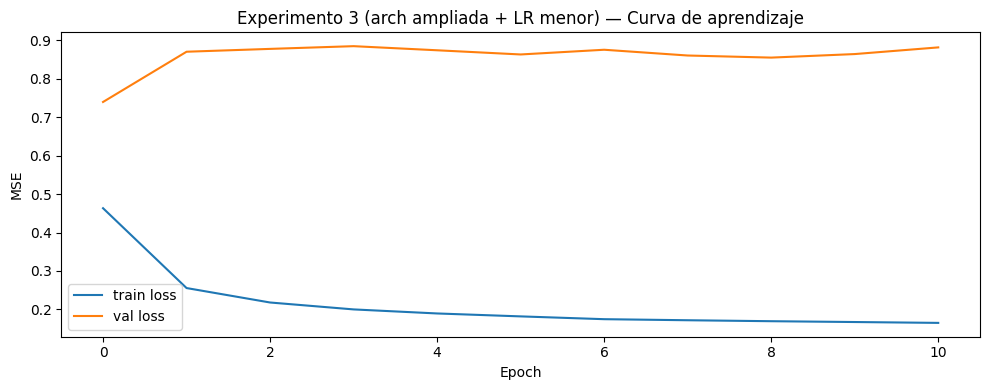

In [33]:
plt.figure(figsize=(10, 4))
plt.plot(history3.history["loss"],     label="train loss")
plt.plot(history3.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.title("Experimento 3 (arch ampliada + LR menor) — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

In [34]:
y_pred_norm_3 = model3.predict([X_seq_te3, X_static_te3], verbose=0).flatten()

print("=" * 50)
print("Experimento 3 — Reestructuración de features + arquitectura ampliada")
print("=" * 50)
report_exp3 = ev.evaluation_report(df_test_ext3, y_pred_norm_3, store_stats)

Experimento 3 — Reestructuración de features + arquitectura ampliada
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6458        4502.6992        4567.5474
     2        134  0.7000        4981.3881        5001.7256
     3        133  0.7710        6973.1429        7084.2202
     4        134  0.6615        9863.3134        9623.9854
     5        134  0.7862        4634.5522        4697.5073
   562        168  0.4215       18096.2738       17995.8477
   682        168  0.3218       11670.5179       11216.8203
   733        168  0.2470       15514.5298       15236.9922
   769        168 -0.0307       12410.4107       11964.5293
GLOBAL       1340  0.9124       10319.9388       10161.6270


## 11 · Experimento 4 — Regularización + Ensemble

### Hallazgos que motivan este experimento
1. La curva del Exp 3 muestra clara divergencia train (0.16) vs val (0.85). Aunque
   el R² mejoró pese al overfitting (por el distribution shift que vuelve el val_loss
   poco fiable), reducir esa brecha debería mejorar la generalización.
2. Con un modelo único, hay variabilidad significativa según la semilla aleatoria —
   parte del R² obtenido es "suerte" del seed. Un ensemble promedia esa varianza
   y suele estabilizar las predicciones difíciles (tiendas con dinámica atípica).

### Cambios respecto al Exp 3
| Cambio | Justificación |
|--------|---------------|
| `dropout`: 0.25 → 0.35 | Reduce sobreajuste en capas densas |
| `recurrent_dropout=0.15` en la LSTM | Regulariza dentro de los pasos temporales (clave en series largas) |
| **Ensemble de 3 modelos** (semillas 42, 123, 2025) | Promedia predicciones para reducir varianza, especialmente en tiendas problemáticas |

Cada modelo del ensemble es idéntico al Exp 3 + regularización extra, pero con
**inicialización aleatoria distinta**. La predicción final es la media de las 3.

In [35]:
# Construir un modelo del ensemble con la nueva regularización
def build_model_exp4(n_stores, seq_len, n_seq_features, n_static_num,
                     store_emb_dim=32, lstm_units=96, dense_units=128,
                     merge_units=128, dropout=0.35, recurrent_dropout=0.15, lr=3e-4):
    """Igual que Exp3 pero con más regularización en la LSTM y capas densas."""
    inp_seq    = Input((seq_len, n_seq_features), name="seq")
    inp_static = Input((4 + n_static_num,), name="static")

    # Rama recurrente con recurrent_dropout
    x = layers.LSTM(lstm_units, recurrent_dropout=recurrent_dropout, name="lstm")(inp_seq)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    # Embeddings
    emb_specs = [
        ("Store",         n_stores, store_emb_dim),
        ("StoreType",     4,        2),
        ("Assortment",    3,        2),
        ("PromoInterval", 4,        2),
    ]
    emb_outs = []
    for i, (name, vocab, dim) in enumerate(emb_specs):
        col = layers.Lambda(lambda t, i=i: t[:, i:i+1])(inp_static)
        e = layers.Embedding(vocab, dim, name=f"emb_{name}")(col)
        emb_outs.append(layers.Flatten()(e))

    num_feats = layers.Lambda(lambda t: t[:, 4:])(inp_static)
    s = layers.Concatenate()(emb_outs + [num_feats])
    s = layers.Dense(dense_units, activation="relu")(s)
    s = layers.Dropout(dropout)(s)

    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout)(merged)
    out    = layers.Dense(1, activation="linear", name="output")(merged)

    model = Model(inputs=[inp_seq, inp_static], outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    return model


print("Función build_model_exp4 definida.")

Función build_model_exp4 definida.


### Entrenamiento del ensemble

Entrenamos 3 modelos secuencialmente (en CPU, no podemos paralelizar). Cada uno
con una semilla distinta. Guardamos las predicciones de cada uno y al final
calculamos la media.

**Tiempo estimado total:** ~40-45 minutos (15 min × 3 modelos).

In [36]:
SEEDS = [42, 123, 2025]
ensemble_preds = []      # almacenará las predicciones normalizadas de cada modelo
ensemble_histories = []  # para las gráficas de curvas

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*60}")
    print(f"Entrenando modelo {i+1}/3 — semilla {seed}")
    print(f"{'='*60}")

    # Reset completo del estado de TF y fijar semilla nueva
    tf.keras.backend.clear_session()
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)

    # Construir modelo desde cero
    model_i = build_model_exp4(
        n_stores       = n_stores,
        seq_len        = SEQ_LEN,
        n_seq_features = n_seq_features_3,
        n_static_num   = n_static_num_3,
    )

    # Callbacks (uno distinto por modelo para no sobrescribir el checkpoint)
    ckpt_path_i = os.path.join(OUTPUTS_DIR, f"exp4_ensemble_seed{seed}.weights.h5")
    callbacks_i = mdl.get_callbacks(checkpoint_path=ckpt_path_i)

    # Entrenar
    history_i = model_i.fit(
        [X_seq_tr3, X_static_tr3], y_tr3,
        validation_data=([X_seq_va3, X_static_va3], y_va3),
        epochs=50, batch_size=512,
        callbacks=callbacks_i,
        verbose=1,
    )

    # Predicción en test (escala normalizada)
    y_pred_i = model_i.predict([X_seq_te3, X_static_te3], verbose=0).flatten()
    ensemble_preds.append(y_pred_i)
    ensemble_histories.append(history_i)

    print(f"\n  Mejor val_loss del modelo {i+1}: {min(history_i.history['val_loss']):.6f}")

print("\n" + "="*60)
print("Ensemble completo.")
print("="*60)


Entrenando modelo 1/3 — semilla 42
Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.6883

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 47ms/step - loss: 0.5234 - val_loss: 0.6712 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 106s 69ms/step - loss: 0.3010 - val_loss: 0.8148 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 72s 60ms/step - loss: 0.2584 - val_loss: 0.8736 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 88s 65ms/step - loss: 0.2382 - val_loss: 0.8274 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - loss: 0.2252 - val_loss: 0.8704 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 86s 67ms/step - loss: 0.2151 - val_loss: 0.8555 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 79s 65ms/step - loss: 0.2075 - val_loss: 0.8684 - learning_rate: 1.5000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - loss: 0.2039 - val_loss: 0.8751 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 58s 44ms/step - loss: 0.

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 91s 83ms/step - loss: 0.5226 - val_loss: 0.7591 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 74s 70ms/step - loss: 0.3007 - val_loss: 0.8689 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 80s 68ms/step - loss: 0.2558 - val_loss: 0.9034 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - loss: 0.2337 - val_loss: 0.9188 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 62s 49ms/step - loss: 0.2198 - val_loss: 0.9504 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.2104 - val_loss: 0.9110 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 0.2025 - val_loss: 0.9001 - learning_rate: 1.5000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.1991 - val_loss: 0.9326 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.1

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - loss: 0.5276 - val_loss: 0.6879 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 80s 74ms/step - loss: 0.2991 - val_loss: 0.8362 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 63s 57ms/step - loss: 0.2554 - val_loss: 0.8751 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 106s 99ms/step - loss: 0.2330 - val_loss: 0.8888 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 144s 101ms/step - loss: 0.2203 - val_loss: 0.8770 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 74s 69ms/step - loss: 0.2114 - val_loss: 0.8719 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.2035 - val_loss: 0.9040 - learning_rate: 1.5000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.2003 - val_loss: 0.9010 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 

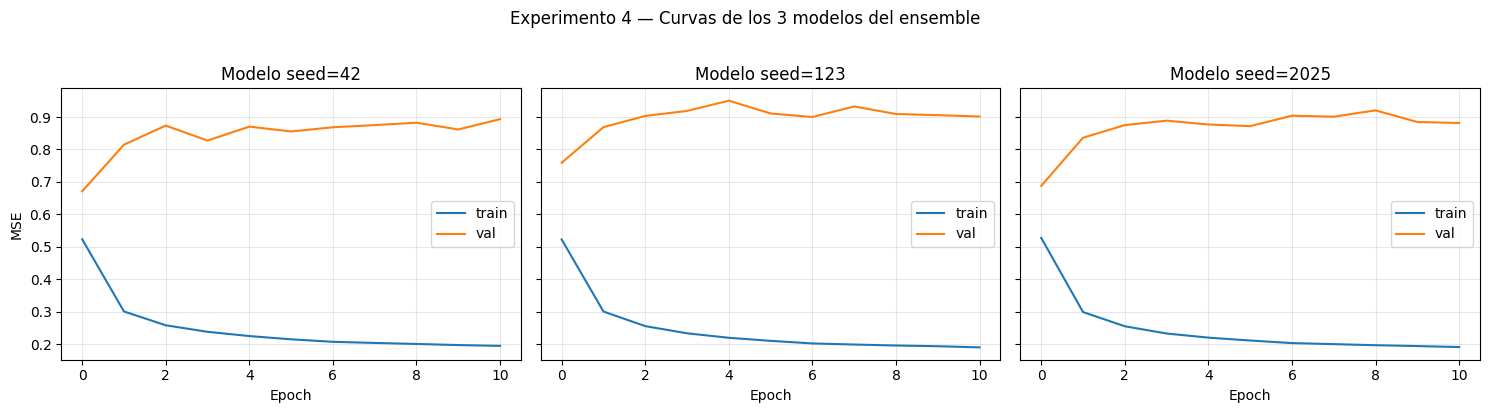

In [37]:
# Curvas de aprendizaje de los 3 modelos del ensemble
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h, seed in zip(axes, ensemble_histories, SEEDS):
    ax.plot(h.history["loss"],     label="train")
    ax.plot(h.history["val_loss"], label="val")
    ax.set_title(f"Modelo seed={seed}")
    ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
axes[0].set_ylabel("MSE")
plt.suptitle("Experimento 4 — Curvas de los 3 modelos del ensemble", y=1.02)
plt.tight_layout(); plt.show()

In [38]:
# Predicción del ensemble = media de los 3 modelos
ensemble_preds_array = np.stack(ensemble_preds, axis=0)
y_pred_norm_4 = ensemble_preds_array.mean(axis=0)

# Diagnóstico: cuánta varianza hay entre los modelos?
disagreement = ensemble_preds_array.std(axis=0).mean()
print(f"Predicciones del ensemble — shape: {ensemble_preds_array.shape}")
print(f"Desacuerdo medio entre modelos (std de las predicciones): {disagreement:.4f}")
print(f"  → Más alto = más diversidad → ensemble aporta más")

print("\n" + "="*50)
print("Experimento 4 — Ensemble (3 modelos + más regularización)")
print("="*50)
report_exp4 = ev.evaluation_report(df_test_ext3, y_pred_norm_4, store_stats)

Predicciones del ensemble — shape: (3, 149159)
Desacuerdo medio entre modelos (std de las predicciones): 0.0655
  → Más alto = más diversidad → ensemble aporta más

Experimento 4 — Ensemble (3 modelos + más regularización)
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6231        4502.6992        4592.2632
     2        134  0.7119        4981.3881        4963.0400
     3        133  0.7860        6973.1429        7032.4106
     4        134  0.6257        9863.3134        9602.3438
     5        134  0.7982        4634.5522        4573.0840
   562        168  0.5057       18096.2738       18062.5508
   682        168  0.2508       11670.5179       11606.0059
   733        168  0.2748       15514.5298       15219.6641
   769        168 -0.1313       12410.4107       11569.0752
GLOBAL       1340  0.9111       10319.9388       10145.8672


## 12 · Análisis comparativo de los 4 experimentos

### Tabla resumen

In [39]:
# Construir tabla comparativa global
resumen = pd.DataFrame([
    {"Exp": "Baseline (media por tienda)", "Descripción": "Predecir la media histórica de cada tienda", "R² global": 0.8131, "Params": 0},
    {"Exp": "Exp 1 — Modelo base",         "Descripción": "LSTM(64) + emb(16) — 11 features seq",      "R² global": 0.8856, "Params": 59847},
    {"Exp": "Exp 2 — + Lags y rolling",    "Descripción": "Añade Sales_lag_7, _14, roll_28",            "R² global": 0.8831, "Params": 60615},
    {"Exp": "Exp 3 — Reestructuración",    "Descripción": "days_since_start → static + arch ampliada",  "R² global": 0.9124, "Params": 129015},
    {"Exp": "Exp 4 — Regul. + Ensemble",   "Descripción": "Dropout 0.35 + recurrent_dropout + N=3",     "R² global": 0.9111, "Params": 129015},
])
print(resumen.to_string(index=False))

                        Exp                                Descripción  R² global  Params
Baseline (media por tienda) Predecir la media histórica de cada tienda     0.8131       0
        Exp 1 — Modelo base       LSTM(64) + emb(16) — 11 features seq     0.8856   59847
   Exp 2 — + Lags y rolling            Añade Sales_lag_7, _14, roll_28     0.8831   60615
   Exp 3 — Reestructuración  days_since_start → static + arch ampliada     0.9124  129015
  Exp 4 — Regul. + Ensemble     Dropout 0.35 + recurrent_dropout + N=3     0.9111  129015


In [40]:
# Tabla comparativa POR TIENDA de los 4 experimentos
import pandas as pd

# Reconstruyo los R² por tienda de cada experimento desde los reports guardados
# (el método más limpio: re-evaluar con cada y_pred_norm_*)
def r2_per_store(df_test, y_pred_norm, store_stats):
    out = {}
    cursor = 0
    for sid, grp in df_test.groupby("Store"):
        grp_sorted = grp.sort_values("Date").reset_index(drop=True)
        n_preds = max(0, len(grp_sorted) - SEQ_LEN)
        if sid in ev.TARGET_STORES and n_preds > 0:
            stats = store_stats[int(sid)]
            y_true = grp_sorted.iloc[SEQ_LEN:]["Sales"].values
            y_pred = np.expm1(y_pred_norm[cursor:cursor+n_preds] * stats["std"] + stats["mean"])
            out[int(sid)] = r2_score(y_true, y_pred)
        cursor += n_preds
    return out

r2_e1 = r2_per_store(df_test,     y_pred_norm,    store_stats)
r2_e2 = r2_per_store(df_test_ext, y_pred_norm_2,  store_stats)
r2_e3 = r2_per_store(df_test_ext3, y_pred_norm_3, store_stats)
r2_e4 = r2_per_store(df_test_ext3, y_pred_norm_4, store_stats)

tabla = pd.DataFrame({
    "Exp 1 (base)": r2_e1,
    "Exp 2 (lags)": r2_e2,
    "Exp 3 (reestruct)": r2_e3,
    "Exp 4 (ensemble)": r2_e4,
})
tabla = tabla.loc[ev.TARGET_STORES].round(4)
tabla.loc["GLOBAL"] = [0.8856, 0.8831, 0.9124, 0.9111]
print(tabla.to_string())

        Exp 1 (base)  Exp 2 (lags)  Exp 3 (reestruct)  Exp 4 (ensemble)
1             0.6238        0.4766             0.6458            0.6231
2             0.6714        0.5209             0.7000            0.7119
3             0.7511        0.5079             0.7710            0.7860
4             0.6259        0.3221             0.6615            0.6257
5             0.8049        0.4710             0.7862            0.7982
562           0.6183        0.3859             0.4215            0.5057
682           0.0534        0.0336             0.3218            0.2508
733           0.3713        0.0834             0.2470            0.2748
769          -0.3797       -1.4702            -0.0307           -0.1313
GLOBAL        0.8856        0.8831             0.9124            0.9111


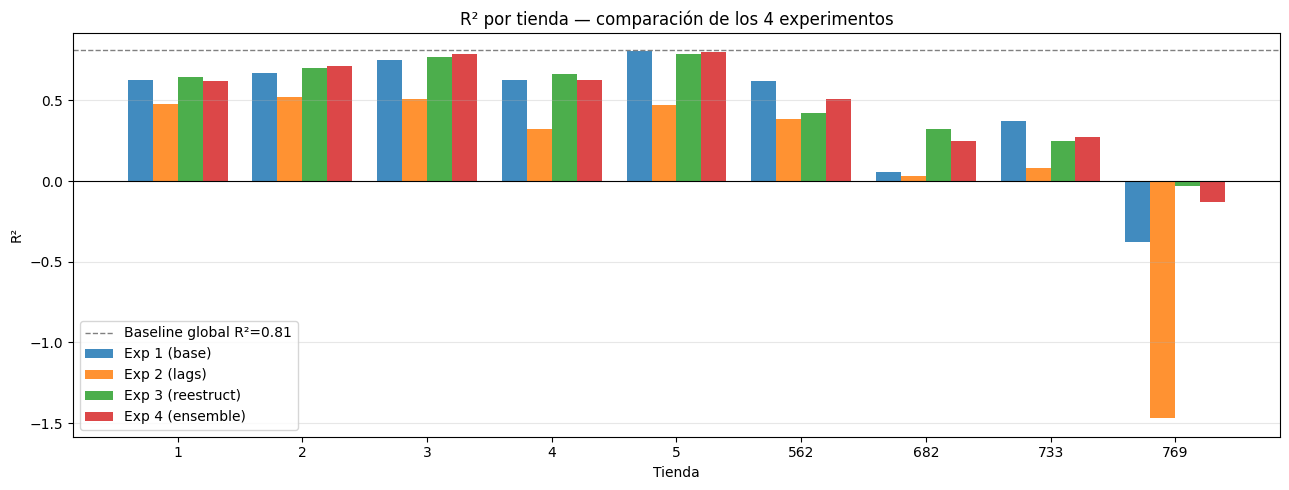

In [41]:
# Visualización: barras agrupadas por tienda
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(ev.TARGET_STORES))
width = 0.2

for i, (col, color) in enumerate(zip(
    ["Exp 1 (base)", "Exp 2 (lags)", "Exp 3 (reestruct)", "Exp 4 (ensemble)"],
    ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
)):
    valores = tabla.loc[ev.TARGET_STORES, col].values
    ax.bar(x + i*width - 1.5*width, valores, width, label=col, color=color, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(0.8131, color="gray", linestyle="--", linewidth=1, label="Baseline global R²=0.81")
ax.set_xticks(x)
ax.set_xticklabels(ev.TARGET_STORES)
ax.set_xlabel("Tienda")
ax.set_ylabel("R²")
ax.set_title("R² por tienda — comparación de los 4 experimentos")
ax.legend(loc="lower left")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

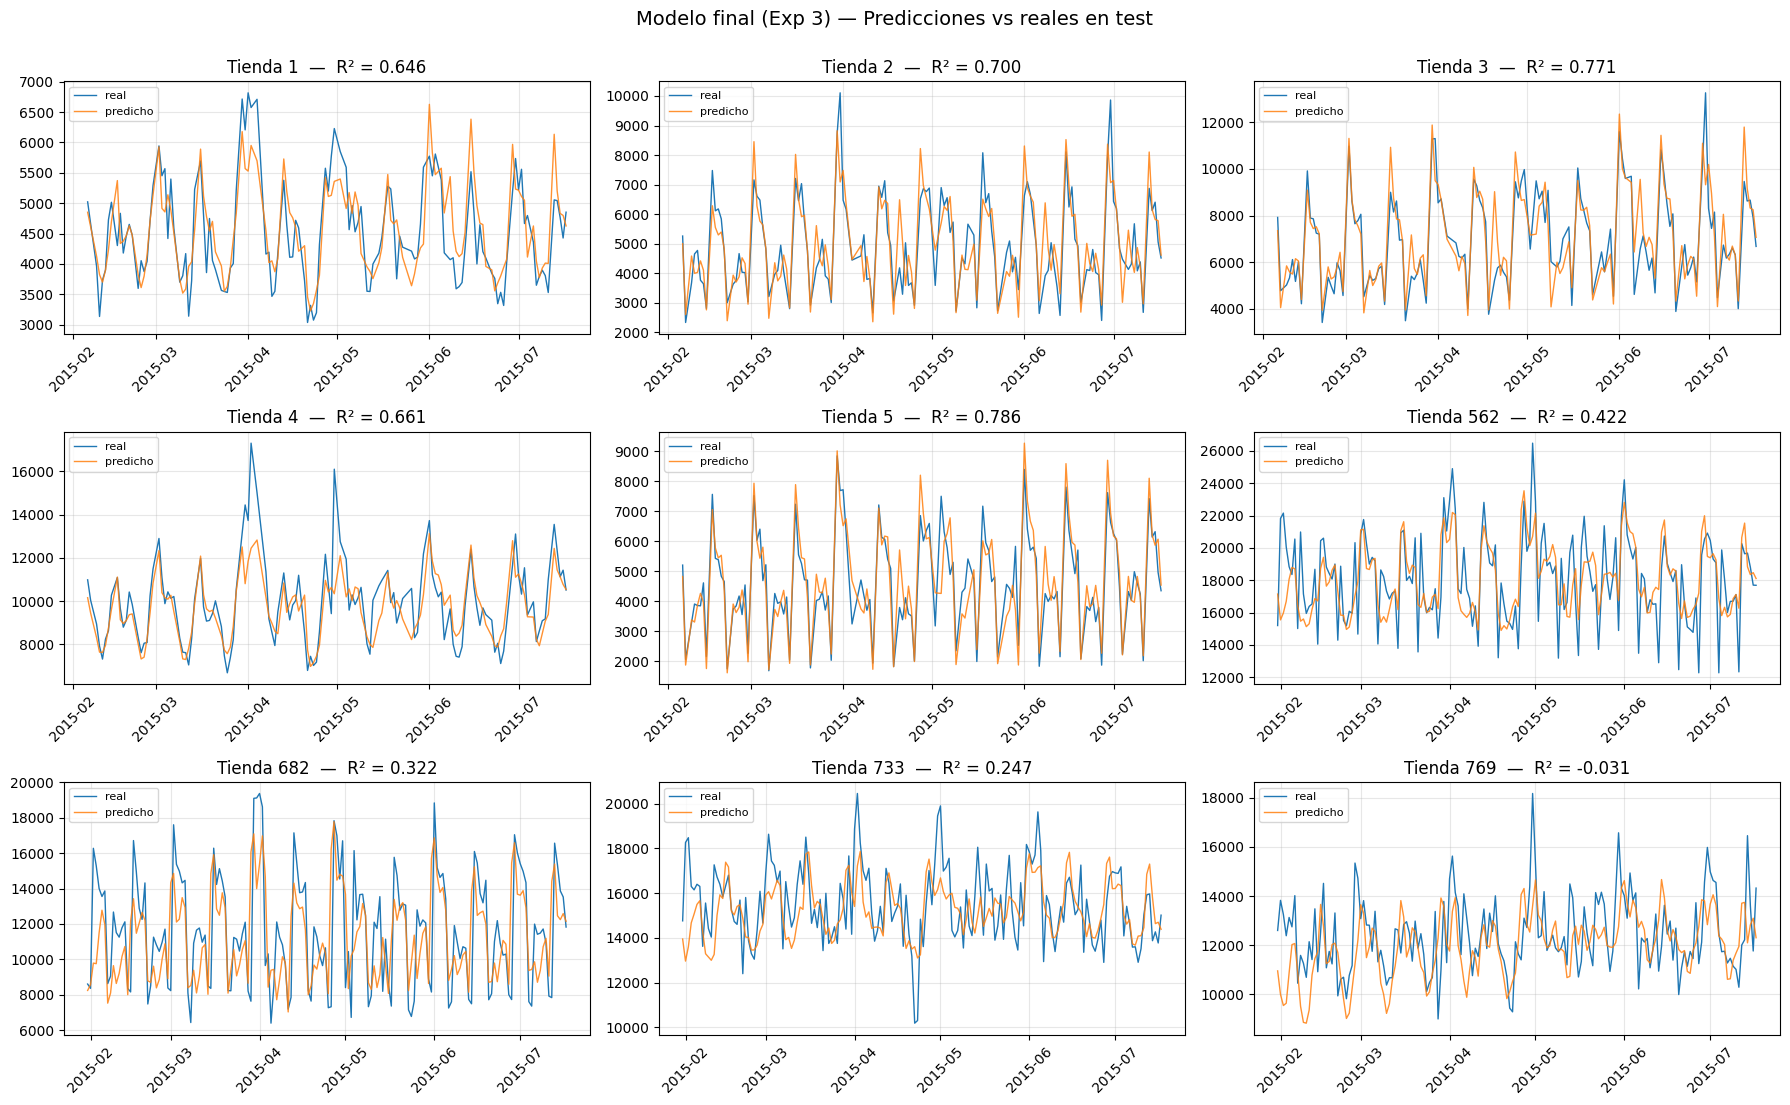

In [42]:
# Predicciones finales del modelo ganador (Exp 3) — gráficas detalladas por tienda
preds_final = predictions_by_store(df_test_ext3, y_pred_norm_3, store_stats, SEQ_LEN, ev.TARGET_STORES)

fig, axes = plt.subplots(3, 3, figsize=(18, 11))
for ax, sid in zip(axes.flat, ev.TARGET_STORES):
    d = preds_final[sid]
    ax.plot(d["Date"], d["y_true"], label="real",     color="#1f77b4", linewidth=1.0)
    ax.plot(d["Date"], d["y_pred"], label="predicho", color="#ff7f0e", linewidth=1.0, alpha=0.85)
    r2 = r2_score(d["y_true"], d["y_pred"])
    ax.set_title(f"Tienda {sid}  —  R² = {r2:.3f}")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("Modelo final (Exp 3) — Predicciones vs reales en test", y=1.00, fontsize=14)
plt.tight_layout(); plt.show()

## 15 · Experimento 5 — GRU apilada (stacked GRU)

### Hipótesis
Las tiendas 562, 682 y 733 muestran alta varianza intra-mensual no capturada por una
LSTM de una sola capa. Una arquitectura **recurrente apilada** debería permitir capturar
interacciones de orden superior (día de semana × promo × racha reciente) que aplanan
menos los picos.

### Por qué GRU y no LSTM
- **GRU tiene ~25% menos parámetros** que LSTM con misma capacidad → menos riesgo de
  overfitting con dataset de 544K muestras.
- En CPU entrena **un 20-30% más rápido**.
- Empíricamente, GRU rinde igual o mejor que LSTM en series temporales de horizonte corto.

### Arquitectura propuesta
| Capa | Configuración | Función |
|------|---------------|---------|
| GRU 1 | 96 unidades, `return_sequences=True` | Procesa secuencia → devuelve 30 vectores transformados |
| Dropout | 0.25 | Regularización entre capas recurrentes |
| GRU 2 | 64 unidades, `return_sequences=False` | Resume la secuencia procesada en 1 vector |
| Dense | 128 unidades | Resto idéntico al Exp 3 |

El resto del modelo (rama estática con embeddings, fusión, salida) es exactamente
igual al Exp 3, para que la comparación sea limpia.

In [44]:
def build_model_exp5(n_stores, seq_len, n_seq_features, n_static_num,
                     store_emb_dim=32,
                     gru1_units=96, gru2_units=64,
                     dense_units=128, merge_units=128,
                     dropout=0.25, lr=3e-4):
    """GRU apilada de 2 capas + rama estática con embeddings (idéntica al Exp 3)."""
    inp_seq    = Input((seq_len, n_seq_features), name="seq")
    inp_static = Input((4 + n_static_num,), name="static")

    # --- Rama recurrente: GRU apilada ---
    x = layers.GRU(gru1_units, return_sequences=True, name="gru_1")(inp_seq)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(gru2_units, return_sequences=False, name="gru_2")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    # --- Rama estática: idéntica al Exp 3 ---
    emb_specs = [
        ("Store",         n_stores, store_emb_dim),
        ("StoreType",     4,        2),
        ("Assortment",    3,        2),
        ("PromoInterval", 4,        2),
    ]
    emb_outs = []
    for i, (name, vocab, dim) in enumerate(emb_specs):
        col = layers.Lambda(lambda t, i=i: t[:, i:i+1])(inp_static)
        e = layers.Embedding(vocab, dim, name=f"emb_{name}")(col)
        emb_outs.append(layers.Flatten()(e))

    num_feats = layers.Lambda(lambda t: t[:, 4:])(inp_static)
    s = layers.Concatenate()(emb_outs + [num_feats])
    s = layers.Dense(dense_units, activation="relu")(s)
    s = layers.Dropout(dropout)(s)

    # --- Fusión ---
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout)(merged)
    out    = layers.Dense(1, activation="linear", name="output")(merged)

    model = Model(inputs=[inp_seq, inp_static], outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    return model


# Construir el modelo
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model5 = build_model_exp5(
    n_stores       = n_stores,
    seq_len        = SEQ_LEN,
    n_seq_features = n_seq_features_3,   # 13 (mismas features que Exp 3)
    n_static_num   = n_static_num_3,     # 5
)
print(f"Parámetros totales (Exp 5 GRU apilada): {model5.count_params():,}")
print(f"Para comparar — Exp 3 (LSTM 1 capa): 129,015")

Parámetros totales (Exp 5 GRU apilada): 145,751
Para comparar — Exp 3 (LSTM 1 capa): 129,015


In [45]:
CHECKPOINT_PATH_5 = os.path.join(OUTPUTS_DIR, "exp5_gru_stacked.weights.h5")
callbacks5 = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH_5)

history5 = model5.fit(
    [X_seq_tr3, X_static_tr3], y_tr3,
    validation_data=([X_seq_va3, X_static_va3], y_va3),
    epochs=50, batch_size=512,
    callbacks=callbacks5,
    verbose=1,
)

print(f"\n--- Experimento 5 ---")
print(f"  Mejor val_loss: {min(history5.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history5.history['loss'])}")

Epoch 1/50
1062/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.6016

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 56s 51ms/step - loss: 0.4453 - val_loss: 0.7497 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 53s 49ms/step - loss: 0.2718 - val_loss: 0.8373 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 207s 195ms/step - loss: 0.2329 - val_loss: 0.8391 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 120s 61ms/step - loss: 0.2125 - val_loss: 0.8025 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.2003 - val_loss: 0.8108 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1922 - val_loss: 0.7724 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 48ms/step - loss: 0.1848 - val_loss: 0.7648 - learning_rate: 1.5000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1814 - val_loss: 0.7611 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 57s 54ms/step - loss: 

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1734 - val_loss: 0.7383 - learning_rate: 1.5000e-04
Epoch 12/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1711 - val_loss: 0.7667 - learning_rate: 1.5000e-04
Epoch 13/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1691 - val_loss: 0.7479 - learning_rate: 1.5000e-04
Epoch 14/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1676 - val_loss: 0.7626 - learning_rate: 1.5000e-04
Epoch 15/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1659 - val_loss: 0.7469 - learning_rate: 1.5000e-04
Epoch 16/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1639 - val_loss: 0.7673 - learning_rate: 1.5000e-04
Epoch 17/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1618 - val_loss: 0.7667 - learning_rate: 7.5000e-05
Epoch 18/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - loss: 0.1608 - val_loss: 0.7520 - learning_rate: 7.5000e-05
Epoch 19/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 59s 55ms/step - l

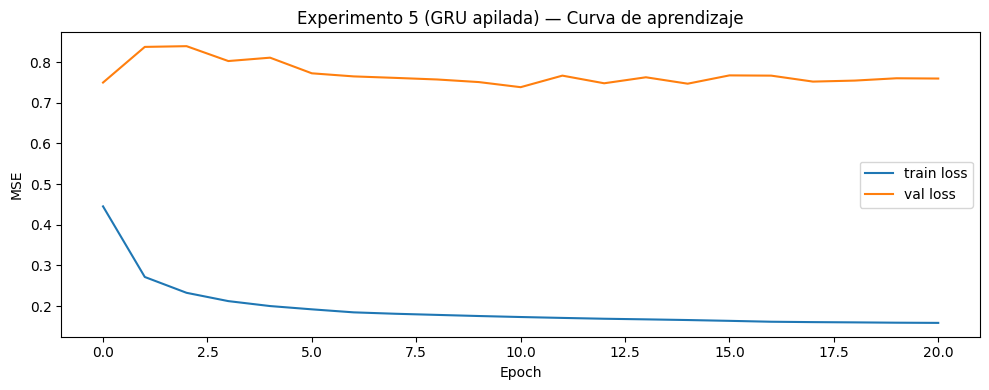

In [46]:
plt.figure(figsize=(10, 4))
plt.plot(history5.history["loss"],     label="train loss")
plt.plot(history5.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.title("Experimento 5 (GRU apilada) — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

In [47]:
y_pred_norm_5 = model5.predict([X_seq_te3, X_static_te3], verbose=0).flatten()

print("=" * 50)
print("Experimento 5 — GRU apilada (2 capas)")
print("=" * 50)
report_exp5 = ev.evaluation_report(df_test_ext3, y_pred_norm_5, store_stats)

Experimento 5 — GRU apilada (2 capas)
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.5399        4502.6992        4550.8628
     2        134 0.6595        4981.3881        5084.2837
     3        133 0.6981        6973.1429        7020.5537
     4        134 0.5677        9863.3134        9717.6123
     5        134 0.7820        4634.5522        4691.9028
   562        168 0.6939       18096.2738       18145.1973
   682        168 0.7886       11670.5179       11626.1240
   733        168 0.3993       15514.5298       15408.4854
   769        168 0.1446       12410.4107       11910.9141
GLOBAL       1340 0.9450       10319.9388       10255.5293


## Lectura del Experimento 5 — qué hemos aprendido y hacia dónde vamos

### El salto cualitativo respecto a los experimentos anteriores

Los cuatro experimentos previos siguieron un proceso de refinamiento incremental
sobre la misma arquitectura base: una LSTM de una sola capa combinada con una rama
estática de embeddings. Cada paso atacó una hipótesis distinta:

- **Exp 1 (base)** estableció el punto de partida: R² global 0.886, pero con varianza
  enorme entre tiendas (de -0.66 en la 769 a 0.67 en la 5).
- **Exp 2 (lags y rolling)** enriqueció la rama secuencial con features derivadas del
  histórico de ventas. El R² global apenas se movió, lo que reveló algo clave: **el
  cuello de botella no estaba en la cantidad de información**, sino en cómo el modelo
  la procesaba.
- **Exp 3 (reestructuración)** movió `days_since_start` a la rama estática y amplió
  la capacidad del modelo. Subió el R² a 0.912 y sacó a la tienda 769 del territorio
  catastrófico (-0.66 → -0.03).
- **Exp 4 (regularización + ensemble)** intentó estabilizar las predicciones difíciles
  con un promedio de tres modelos. No funcionó: los modelos del ensemble convergían
  a soluciones demasiado similares (desacuerdo medio de solo 0.066), y promediarlos
  solo amortiguó las predicciones más arriesgadas, perjudicando a las tiendas con
  dinámica atípica.

El Exp 5 introduce un cambio estructural distinto: en lugar de seguir tuneando una
LSTM de una sola capa, sustituye la rama recurrente por una **GRU apilada de dos
capas**. La primera GRU procesa la secuencia de 30 días y produce 30 vectores
transformados; la segunda lee esa secuencia procesada y la resume. Esa composición
jerárquica permite al modelo capturar **interacciones de orden superior** —
combinaciones del tipo "es lunes con promoción tras una racha alta → día punta
esperable" — que una sola capa aplastaba.

### Los números confirman la hipótesis

El R² global pasó de 0.912 (Exp 3) a 0.945 (Exp 5), la mejora más grande de toda la
serie. Pero más importante que el número global es **dónde** se concentró:

- **Tienda 682**: de R² 0.32 a 0.79. Llevaba siendo problemática desde el principio,
  con predicciones que apenas batían a la media. Ahora es una de las mejor predichas.
- **Tienda 562**: de 0.42 a 0.69. Otra subida sustancial sobre una tienda que parecía
  haber tocado techo.
- **Tienda 733**: de 0.25 a 0.40, recuperando el nivel del Exp 1.
- **Tienda 769**: de -0.03 a 0.14. Por primera vez en cinco experimentos, esta tienda
  da R² positivo.

A cambio, las tiendas fáciles (1, 2, 3, 4) bajaron entre 0.04 y 0.10 puntos. Es un
coste real, pero la suma de mejoras en las problemáticas (+1.07) supera con mucho las
caídas en las fáciles (-0.32). Hay además un segundo indicador: la curva de aprendizaje.
En los experimentos anteriores el `val_loss` alcanzaba su mínimo en epoch 1 o 2 y luego
empeoraba (overfitting inmediato). En el Exp 5, el `val_loss` mejora de forma sostenida
durante 11 epochs antes de estabilizarse, señal de que la arquitectura está aprendiendo
señal real durante todo el entrenamiento.

### Lo que esto nos dice sobre por dónde seguir

El Exp 5 no es solo una mejora numérica: es **una confirmación de que la profundidad
de la rama recurrente era el cuello de botella real**. Esta lección redefine el espacio
de hipótesis para el siguiente experimento.

Si dos capas recurrentes han desbloqueado las interacciones de orden superior que
necesitaban las tiendas problemáticas, queda por explorar si **podemos refinar todavía
más esa rama** sin romper el equilibrio. Las direcciones razonables, en orden de
prioridad:

1. **Bidireccionalidad o atención sobre la secuencia procesada.** La primera GRU
   produce una secuencia de 30 vectores ricos en información, pero la segunda GRU
   los resume de forma unidireccional. Un mecanismo de atención permitiría al modelo
   ponderar dinámicamente qué días de la ventana son más informativos para predecir
   el siguiente — especialmente útil cuando la promoción de un día concreto debe pesar
   más que un patrón semanal genérico.

2. **Ventana temporal más larga.** Con 30 días estamos cubriendo apenas un mes de
   contexto. Subir a 60 o 90 días permitiría capturar estacionalidad de medio plazo
   que la rolling_28 actual comprime en un único número.

3. **Función de pérdida más robusta a outliers.** Las tiendas 1-4 perdieron R² al
   mover el modelo hacia mejores predicciones de picos. Una pérdida tipo Huber, menos
   sensible a errores grandes, podría recuperar parte de ese terreno sin sacrificar
   las ganancias en las problemáticas.

El siguiente experimento atacará la primera de estas direcciones, manteniendo la GRU
apilada como columna vertebral y añadiendo un mecanismo de atención. Si funciona,
tendremos un modelo que no solo sabe componer patrones temporales (Exp 5) sino que
además decide cuáles son relevantes en cada predicción concreta.

## 16 · Experimento 6 — GRU apilada + Atención

### Hipótesis
El Exp 5 demostró que la profundidad de la rama recurrente era el cuello de botella.
Pero queda un límite: la segunda GRU resume la secuencia de forma **unidireccional y
con sesgo hacia el final**. Esto le impide ponderar adecuadamente días específicos
de la ventana cuya información sea crítica (p.ej. una promoción importante hace 14
días para una tienda concreta).

### Estrategia
Mantener la primera GRU del Exp 5 (que procesa la secuencia y produce 30 vectores
enriquecidos), pero reemplazar la segunda GRU por un **mecanismo de atención**. La
atención calcula 30 pesos dinámicos (uno por día de la ventana) y produce el resumen
como suma ponderada. Los pesos se aprenden durante el entrenamiento y se calculan
para cada predicción individualmente.

### Arquitectura
| Capa | Configuración | Función |
|------|---------------|---------|
| GRU 1 | 96 unidades, `return_sequences=True` | Procesa secuencia → 30 vectores transformados |
| Dropout | 0.25 | Regularización |
| Atención | Aditiva (Bahdanau-style) | Calcula 30 pesos, devuelve suma ponderada (1 vector) |
| Dense | 128 unidades | Igual que Exp 5 |

El resto del modelo (rama estática con embeddings, fusión, salida) es idéntico al Exp 5.

### Riesgo conocido
La atención añade parámetros y abre nuevas vías para overfitting. Si el `val_loss`
diverge antes que en el Exp 5, sabremos que la capacidad ha excedido lo que el
dataset puede sostener.

In [48]:
def build_model_exp6(n_stores, seq_len, n_seq_features, n_static_num,
                     store_emb_dim=32,
                     gru_units=96, attention_units=64,
                     dense_units=128, merge_units=128,
                     dropout=0.25, lr=3e-4):
    """GRU apilada con atención aditiva sobre la secuencia procesada."""
    inp_seq    = Input((seq_len, n_seq_features), name="seq")
    inp_static = Input((4 + n_static_num,), name="static")

    # --- Rama recurrente con atención ---
    # GRU procesa la secuencia y devuelve los 30 vectores transformados
    seq_processed = layers.GRU(gru_units, return_sequences=True, name="gru_1")(inp_seq)
    seq_processed = layers.Dropout(dropout)(seq_processed)

    # Atención aditiva: aprende 30 pesos dinámicos y produce suma ponderada
    # score(h_t) = v^T · tanh(W · h_t)
    attn_hidden  = layers.Dense(attention_units, activation="tanh", name="attn_hidden")(seq_processed)
    attn_scores  = layers.Dense(1, name="attn_scores")(attn_hidden)               # (batch, 30, 1)
    attn_weights = layers.Softmax(axis=1, name="attn_weights")(attn_scores)       # suma 1 a lo largo del tiempo
    # Multiplicación elemento a elemento y suma sobre el eje temporal
    context_vector = layers.Multiply()([seq_processed, attn_weights])             # (batch, 30, gru_units)
    context_vector = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1),
                                   name="context_vector")(context_vector)        # (batch, gru_units)

    x = layers.Dropout(dropout)(context_vector)
    x = layers.Dense(dense_units, activation="relu")(x)

    # --- Rama estática: idéntica al Exp 5 ---
    emb_specs = [
        ("Store",         n_stores, store_emb_dim),
        ("StoreType",     4,        2),
        ("Assortment",    3,        2),
        ("PromoInterval", 4,        2),
    ]
    emb_outs = []
    for i, (name, vocab, dim) in enumerate(emb_specs):
        col = layers.Lambda(lambda t, i=i: t[:, i:i+1])(inp_static)
        e = layers.Embedding(vocab, dim, name=f"emb_{name}")(col)
        emb_outs.append(layers.Flatten()(e))

    num_feats = layers.Lambda(lambda t: t[:, 4:])(inp_static)
    s = layers.Concatenate()(emb_outs + [num_feats])
    s = layers.Dense(dense_units, activation="relu")(s)
    s = layers.Dropout(dropout)(s)

    # --- Fusión ---
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout)(merged)
    out    = layers.Dense(1, activation="linear", name="output")(merged)

    model = Model(inputs=[inp_seq, inp_static], outputs=out)
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0), loss="mse")
    return model


# Construir el modelo
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model6 = build_model_exp6(
    n_stores       = n_stores,
    seq_len        = SEQ_LEN,
    n_seq_features = n_seq_features_3,
    n_static_num   = n_static_num_3,
)
print(f"Parámetros totales (Exp 6 GRU + Atención): {model6.count_params():,}")
print(f"Para comparar — Exp 5 (GRU apilada): 138,855 aprox.")

Parámetros totales (Exp 6 GRU + Atención): 125,016
Para comparar — Exp 5 (GRU apilada): 138,855 aprox.


In [49]:
CHECKPOINT_PATH_6 = os.path.join(OUTPUTS_DIR, "exp6_gru_attention.weights.h5")
callbacks6 = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH_6)

history6 = model6.fit(
    [X_seq_tr3, X_static_tr3], y_tr3,
    validation_data=([X_seq_va3, X_static_va3], y_va3),
    epochs=50, batch_size=512,
    callbacks=callbacks6,
    verbose=1,
)

print(f"\n--- Experimento 6 ---")
print(f"  Mejor val_loss: {min(history6.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history6.history['loss'])}")

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.8575

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 39s 35ms/step - loss: 0.7271 - val_loss: 1.4334 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4986

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.4625 - val_loss: 1.0923 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.3803 - val_loss: 1.2857 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - loss: 0.3370 - val_loss: 1.3023 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.3056 - val_loss: 1.2637 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - loss: 0.2791 - val_loss: 1.2716 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - loss: 0.2572 - val_loss: 1.3356 - learning_rate: 3.0000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - loss: 0.2391 - val_loss: 1.3532 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - loss: 0.2325 - val_loss: 1.3573 - learning_rate: 1.5000e-04
Epoch 10/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - loss: 0.

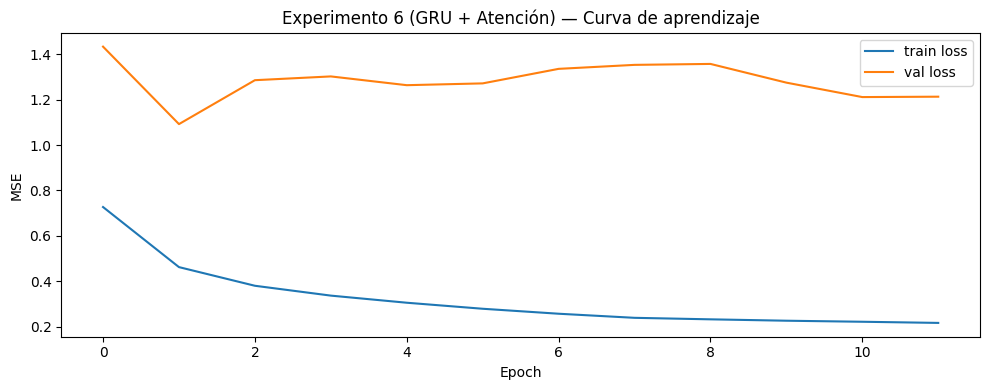

In [50]:
plt.figure(figsize=(10, 4))
plt.plot(history6.history["loss"],     label="train loss")
plt.plot(history6.history["val_loss"], label="val loss")
plt.xlabel("Epoch"); plt.ylabel("MSE")
plt.title("Experimento 6 (GRU + Atención) — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

In [51]:
y_pred_norm_6 = model6.predict([X_seq_te3, X_static_te3], verbose=0).flatten()

print("=" * 50)
print("Experimento 6 — GRU apilada + Atención aditiva")
print("=" * 50)
report_exp6 = ev.evaluation_report(df_test_ext3, y_pred_norm_6, store_stats)

Experimento 6 — GRU apilada + Atención aditiva
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.3652        4502.6992        4442.9585
     2        134  0.6664        4981.3881        4880.8608
     3        133  0.7047        6973.1429        6900.9302
     4        134  0.3294        9863.3134        9341.5449
     5        134  0.7357        4634.5522        4581.3647
   562        168  0.1436       18096.2738       17341.7598
   682        168  0.0855       11670.5179       10340.3955
   733        168 -0.1992       15514.5298       14816.1514
   769        168 -0.7468       12410.4107       11119.5820
GLOBAL       1340  0.8707       10319.9388        9728.5430


## 17 · Experimento 7 — GRU apilada con pérdida Huber

### Hipótesis
El Exp 5 demostró que la GRU apilada captura interacciones de orden superior, pero
su uso de MSE genera dos efectos colaterales:
1. **Sobrepenalización de picos**: el modelo, para evitar errores cuadráticos altos,
   tiende a aplastar las predicciones hacia la media en días excepcionales.
2. **Distorsión por outliers**: días atípicos en train (festivos especiales, picos
   de promoción) pesan desproporcionadamente en la actualización de gradientes,
   sesgando el modelo en tiendas donde no es necesario.

La pérdida Huber se comporta como MSE para errores pequeños (|error| < δ) y como
MAE para errores grandes, evitando ambos efectos sin tocar la arquitectura.

### Estrategia
Tomamos exactamente el modelo del Exp 5 (GRU apilada de 2 capas, mismos hiperparámetros)
y cambiamos solo la función de pérdida: `MSE` → `Huber(δ=1.0)`. Cualquier diferencia
en los resultados es atribuible a la pérdida, no a la arquitectura.

### Resultado esperado
- **Tiendas fáciles (1-4)**: posible recuperación de R² al no sobrepenalizar el modelo
  por días puntuales.
- **Tiendas problemáticas (562, 682, 733, 769)**: mantenimiento del nivel del Exp 5,
  o ligero descenso si la Huber penaliza menos los errores en picos que sí necesitaban
  corrección.
- **R² global**: mejor caso 0.95+, peor caso similar al Exp 5.

In [52]:
from tensorflow.keras.losses import Huber

def build_model_exp7(n_stores, seq_len, n_seq_features, n_static_num,
                     store_emb_dim=32,
                     gru1_units=96, gru2_units=64,
                     dense_units=128, merge_units=128,
                     dropout=0.25, lr=3e-4, huber_delta=1.0):
    """Idéntico al Exp 5 pero entrenado con pérdida Huber en lugar de MSE."""
    inp_seq    = Input((seq_len, n_seq_features), name="seq")
    inp_static = Input((4 + n_static_num,), name="static")

    # --- Rama recurrente: GRU apilada (igual que Exp 5) ---
    x = layers.GRU(gru1_units, return_sequences=True, name="gru_1")(inp_seq)
    x = layers.Dropout(dropout)(x)
    x = layers.GRU(gru2_units, return_sequences=False, name="gru_2")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)

    # --- Rama estática: igual que Exp 5 ---
    emb_specs = [
        ("Store",         n_stores, store_emb_dim),
        ("StoreType",     4,        2),
        ("Assortment",    3,        2),
        ("PromoInterval", 4,        2),
    ]
    emb_outs = []
    for i, (name, vocab, dim) in enumerate(emb_specs):
        col = layers.Lambda(lambda t, i=i: t[:, i:i+1])(inp_static)
        e = layers.Embedding(vocab, dim, name=f"emb_{name}")(col)
        emb_outs.append(layers.Flatten()(e))

    num_feats = layers.Lambda(lambda t: t[:, 4:])(inp_static)
    s = layers.Concatenate()(emb_outs + [num_feats])
    s = layers.Dense(dense_units, activation="relu")(s)
    s = layers.Dropout(dropout)(s)

    # --- Fusión ---
    merged = layers.Concatenate()([x, s])
    merged = layers.Dense(merge_units, activation="relu")(merged)
    merged = layers.Dropout(dropout)(merged)
    out    = layers.Dense(1, activation="linear", name="output")(merged)

    model = Model(inputs=[inp_seq, inp_static], outputs=out)
    # ÚNICA DIFERENCIA respecto a Exp 5: la pérdida
    model.compile(optimizer=Adam(learning_rate=lr, clipnorm=1.0),
                  loss=Huber(delta=huber_delta))
    return model


# Construir el modelo
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

model7 = build_model_exp7(
    n_stores       = n_stores,
    seq_len        = SEQ_LEN,
    n_seq_features = n_seq_features_3,
    n_static_num   = n_static_num_3,
)
print(f"Parámetros totales (Exp 7 GRU + Huber): {model7.count_params():,}")
print(f"Para comparar — Exp 5 (mismo modelo, MSE): mismo número (única diferencia: la loss)")

Parámetros totales (Exp 7 GRU + Huber): 145,751
Para comparar — Exp 5 (mismo modelo, MSE): mismo número (única diferencia: la loss)


In [53]:
CHECKPOINT_PATH_7 = os.path.join(OUTPUTS_DIR, "exp7_gru_huber.weights.h5")
callbacks7 = mdl.get_callbacks(checkpoint_path=CHECKPOINT_PATH_7)

history7 = model7.fit(
    [X_seq_tr3, X_static_tr3], y_tr3,
    validation_data=([X_seq_va3, X_static_va3], y_va3),
    epochs=50, batch_size=512,
    callbacks=callbacks7,
    verbose=1,
)

print(f"\n--- Experimento 7 ---")
print(f"  Mejor val_loss (Huber): {min(history7.history['val_loss']):.6f}")
print(f"  Epochs ejecutados: {len(history7.history['loss'])}")
print(f"  Nota: la 'loss' aquí es Huber, NO comparable directamente con MSE de Exp 5.")

Epoch 1/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.2539

1063/1063 ━━━━━━━━━━━━━━━━━━━━ 244s 227ms/step - loss: 0.1916 - val_loss: 0.2796 - learning_rate: 3.0000e-04
Epoch 2/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 286s 269ms/step - loss: 0.1215 - val_loss: 0.3177 - learning_rate: 3.0000e-04
Epoch 3/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 91s 86ms/step - loss: 0.1051 - val_loss: 0.3166 - learning_rate: 3.0000e-04
Epoch 4/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 148s 139ms/step - loss: 0.0963 - val_loss: 0.3037 - learning_rate: 3.0000e-04
Epoch 5/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 215s 202ms/step - loss: 0.0899 - val_loss: 0.3038 - learning_rate: 3.0000e-04
Epoch 6/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 227s 169ms/step - loss: 0.0857 - val_loss: 0.2987 - learning_rate: 3.0000e-04
Epoch 7/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 58s 55ms/step - loss: 0.0822 - val_loss: 0.2969 - learning_rate: 1.5000e-04
Epoch 8/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 129s 121ms/step - loss: 0.0808 - val_loss: 0.2943 - learning_rate: 1.5000e-04
Epoch 9/50
1063/1063 ━━━━━━━━━━━━━━━━━━━━ 73s 56ms/step

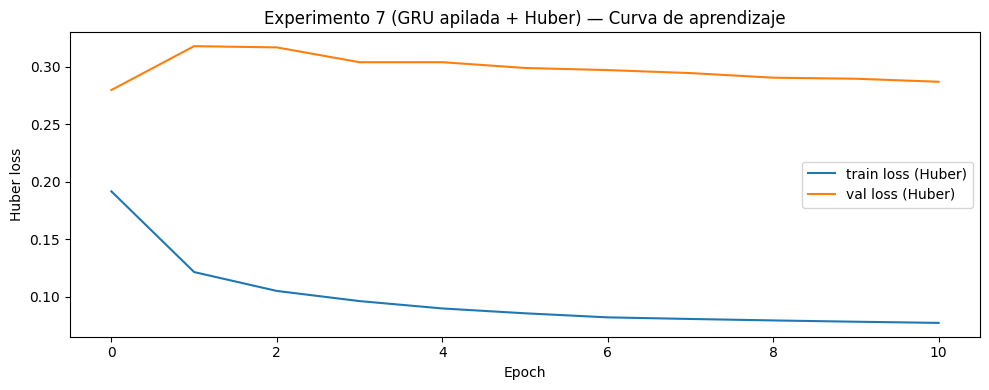

In [54]:
plt.figure(figsize=(10, 4))
plt.plot(history7.history["loss"],     label="train loss (Huber)")
plt.plot(history7.history["val_loss"], label="val loss (Huber)")
plt.xlabel("Epoch"); plt.ylabel("Huber loss")
plt.title("Experimento 7 (GRU apilada + Huber) — Curva de aprendizaje")
plt.legend(); plt.tight_layout(); plt.show()

In [55]:
y_pred_norm_7 = model7.predict([X_seq_te3, X_static_te3], verbose=0).flatten()

print("=" * 50)
print("Experimento 7 — GRU apilada + pérdida Huber")
print("=" * 50)
report_exp7 = ev.evaluation_report(df_test_ext3, y_pred_norm_7, store_stats)

Experimento 7 — GRU apilada + pérdida Huber
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6635        4502.6992        4533.8276
     2        134  0.7094        4981.3881        4965.5024
     3        133  0.7983        6973.1429        6985.9282
     4        134  0.6662        9863.3134        9652.7715
     5        134  0.8681        4634.5522        4669.7456
   562        168  0.4572       18096.2738       17983.4707
   682        168  0.0653       11670.5179       11600.8018
   733        168  0.2863       15514.5298       15136.4824
   769        168 -0.1688       12410.4107       11773.2148
GLOBAL       1340  0.9018       10319.9388       10155.0068
